In [6]:
#for reading files
import glob
import tifffile

#math computation and data organization
import numpy as np
import math
import scipy
from scipy.ndimage import binary_erosion, binary_fill_holes
from scipy import optimize
from scipy.optimize import curve_fit
import pandas as pd

# For loading bars
from tqdm.notebook import tqdm as tqdm

#For image plotting
import skimage.io

#For identifying aster center
from skimage.filters import threshold_otsu, gaussian, threshold_mean
from skimage.measure import regionprops
import cv2

#for fitting
from lmfit import minimize, Parameters, fit_report

#for image registration
from skimage.registration import phase_cross_correlation
import os

#Matplotlib plotting packages
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import patches
from matplotlib import gridspec

import seaborn as sns
sns.set_context("poster")
sns.set_style("ticks")

#Movie
import celluloid as cell
import matplotlib.animation as animation

#for saving data
import csv
import h5py

#custom analysis packages
import aster_packages as ap #### commented out 20241114 since lucida fonts are not installed...

# Thing to enable lovely parallelization
import concurrent.futures

# Enable repeat from itertools for parallel
import itertools

#time elements for testing runtimes and using todays date
import time
from datetime import datetime

In [7]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42  # Use TrueType fonts for editable text in PDFs

In [8]:
######### gabe hacky styling to emulate some of PBoC Phillips lab style conventions, however hacky. tries to make easier for nigel++
## Styling
import matplotlib
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context("poster")
# sns.set_style('ticks')

import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Set the property to save figures with text as text, not paths
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# default good PBoC colors
baseBlendColor=(224/255, 219/255, 209/255,1) # default background for plots
contrastColor=(209/255, 193/255, 171/255,1) # slightly darker tan for contrasts, e.g. in inset boxes
yellowTanHighlightBoxColor='#FEF0C6'
goodGreyGreenArrowColor='#CCD4C9'

### Griffin style invocation

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.path import Path
from matplotlib.patches import BoxStyle
from matplotlib.offsetbox import AnchoredText

def plotting_style(grid=False):
    """
    Sets the style to the publication style. To instantiate, simply call
    plotting_style() at the beginning of your script or notebook to force
    all matplotlib plots to adopt the scheme.

    Parameters
    ----------
    grid: bool
      If True, plots will have a thin, white grid in the background. Default
      is False.

    Returns
    -------
    colors: dict
      Returns a dictionary of the standard PBoC 2e color palette.
    """
    rc = {'axes.facecolor': '#E3DCD0',
#               'axes.spines.top': False,
#               'axes.spines.right': False,
#               'axes.spines.left': False,  # Ensure left spine is present
#               'axes.spines.bottom': False,  # Ensure bottom spine is present
#               'axes.spines.left': False, #{'color': '#E3DCD0', 'linewidth': 1.5},  # Set the spine color to the background color
#               'axes.spines.bottom': False, #{'color': '#E3DCD0', 'linewidth': 1.5},  # Set the spine color to the background color
          #'font.family': '/usr/share/fonts/truetype/LucidaSansOT.otf', #'LucidaSansOT.otf',
          'grid.linestyle': '-',
          'grid.linewidth': 0.5,
          'grid.alpha': 0.75,
          'grid.color': '#ffffff',
          'axes.grid': grid,
          'ytick.direction': 'in',
          'xtick.direction': 'in',
          'xtick.gridOn': grid,
          'ytick.gridOn': grid,
#               'ytick.major.width':8,
#               'xtick.major.width':8,
#               'ytick.major.size': 8,
#               'xtick.major.size': 8,
          'mathtext.fontset': 'stixsans',
          'mathtext.sf': 'sans',
          'legend.frameon': True,
          'legend.facecolor': '#FFEDCE',
          'figure.dpi': 150,
          'xtick.color': 'k',
          'ytick.color': 'k'
         }
    plt.rc('text.latex', preamble=r'\usepackage{sfmath}')
    plt.rc('mathtext', fontset='stixsans', sf='sans')
    sns.set_style('darkgrid', rc=rc)
    return color_palette()

def color_palette():
    """
    Returns a dictionary of the PBOC color palette
    """
    return {'green': '#7AA974', 'light_green': '#BFD598',
              'pale_green': '#DCECCB', 'yellow': '#EAC264',
              'light_yellow': '#F3DAA9', 'pale_yellow': '#FFEDCE',
              'blue': '#738FC1', 'light_blue': '#A9BFE3',
              'pale_blue': '#C9D7EE', 'red': '#D56C55', 'light_red': '#E8B19D',
              'pale_red': '#F1D4C9', 'purple': '#AB85AC',
              'light_purple': '#D4C2D9', 'dark_green':'#7E9D90', 'dark_brown':'#905426'}

def titlebox(
    ax, text, color, bgcolor=None, size=8, boxsize=0.1, pad=0.05, **kwargs
):
    """
    Sets a colored title box above the plot, spanning the entire plot width.

    Parameters
    ----------
    ax : matplotlib axis object
      The axis on which you want to add the titlebox.
    text: str
      The title tect
    bgcolor: str or None
      The background color of the title box. Default is no color (blank).
    size:  int
      Size of the text font
    boxsize: float [0, 1]
      Fraction of the total plot height to be occupied by the box. Default is 10% (0.1).
    pad: float
      The padding space between the title box and the top of the plot.

    """
    boxsize=str(boxsize * 100)  + '%'
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("top", size=boxsize, pad=pad)
    cax.get_xaxis().set_visible(False)
    cax.get_yaxis().set_visible(False)
    cax.spines["top"].set_visible(False)
    cax.spines["right"].set_visible(False)
#     cax.spines["bottom"].set_visible(False)
#     cax.spines["left"].set_visible(False)

#     cax.spines["bottom"].set_visible(True)
#     cax.spines["left"].set_visible(True)
#     cax.spines["left"].set_color("white")
#     cax.spines["bottom"].set_color("white")
#     cax.spines["bottom"].set_color("white")

#     cax.set_ticks_position('both')  # Adding ticks to both top and bottom
#     cax.yaxis.set_tick_params(direction='in', which='both', color='white')  # The bottom will maintain the default of 'out'


    plt.setp(cax.spines.values(), color=color)
    if bgcolor != None:
        cax.set_facecolor(bgcolor)
    else:
        cax.set_facecolor("white")
    at = AnchoredText(text, loc=10, frameon=False, prop=dict(size=size, color=color))
    cax.add_artist(at)


### Now actually call it
plotting_style()

import matplotlib.patheffects as pe
matplotlib.rcParams['axes.autolimit_mode'] = 'data'

In [9]:
def grab_dark_avg(file_path_dark):
    """
    Imports a dark image.
 
    Parameters:
    file_path_dark (string): Data path for a dark image.
    
    Returns:
    dark_avg (numpy.ndarray): Dark image as a 2D array.
    """
    dark_files = np.sort(glob.glob(file_path_dark))
    dark_ims = ap.file_to_image(dark_files)
    dark_avg = np.average(dark_ims, axis=0)
    return dark_avg

In [10]:
def backSubtract(arrs, dark_avg):
    """
    Subtracts camera dark noise from images
    
    Parameters:
    arrs (lsit): list of 3D numpy.ndarray's containing aster images where each array is from a different fluorescent channel.
    dark_avg (numpy.ndarray): 2D array image taken with the camera shutter closed of shape (m, n)
    
    Returns:
    (list): list of 3D numpy.ndarray's with dark camera noise subtracted.
    """
    return [arr-dark_avg for arr in arrs] # save processed images

In [11]:
def fit_bivariate_quadratic_anyShape(vals, coord):
    """
    Fits a bivariate quadratic polynomial to the intensity values of a grayscale image.
    
    Parameters:
    binary_im (numpy.ndarray): Grayscale image of shape (M, N).
    
    Returns:
    coefficients (numpy.ndarray): Coefficients of the fitted polynomial [a00, a10, a01, a20, a11, a02].
    """
    # Flatten the matrices for the least squares fitting
    I_flat = coord[0]
    J_flat = coord[1]
    Z_flat = vals

    # Create the design matrix for the polynomial terms
    A = np.vstack([I_flat**2, J_flat**2, I_flat*J_flat, I_flat, J_flat, np.ones_like(I_flat)]).T

    # Solve for the coefficients using least squares
    coefficients, _, _, _ = np.linalg.lstsq(A, Z_flat, rcond=None)

    return coefficients

def evaluateBivPoly_anyShape(vals,coord, clipPixVals=False):
    """ Given coordinates, this function returns the best-fit bivariate polynomial for image. """

    if clipPixVals:
        # reduce likelihood of fits to outrageous extraneous pixels if naughty
        mask=(vals <= np.percentile(vals, 99.99)) & (vals >= np.percentile(vals, 0.1))
        vals=vals[mask]
        #coord=coord[mask]
        coord=(coord[0][mask], coord[1][mask])
    
    coefficients=fit_bivariate_quadratic_anyShape(vals, coord);
    I, J = coord[0], coord[1]
    Z_fitted = (coefficients[0] * I**2 + coefficients[1] * J**2 +
            coefficients[2] * I * J + coefficients[3] * I +
            coefficients[4] * J + coefficients[5])
    if not clipPixVals:
        return Z_fitted
    else:
        return Z_fitted, coord

In [12]:
def norm_unev(arrs_sub, mask_coords, allmask_coords):
    """
    Corrects uneven illumination by fitting an image to a bivariate polynomial, normalizing the polynomial, and dividing an array of images by this normalized matrix.
    
    Parameters:
    arrs_sub (list): Dark image subtracted list of image arrays.
    mask_coords (length 2 tuple): illumination mask coordinates (for one image)
    allmask_coords (slice): slice containing all the illumination coordinates with an extra dimension to account for all timepoints
    
    Returns:
    arr_ev (list): list of image arrays after the evening process.
    """
    #norm_mats = []
    arrs_ev = []
    
    for arr in arrs_sub:
        #compute the bivariate filter
        biv_filt = np.zeros_like(arr[0])
        biv_filt[mask_coords] = evaluateBivPoly_anyShape(arr[0, :, :][mask_coords], mask_coords)
        #norm_mats.append(norm_mat)
        
        #scale the normalization matrix such that the average value after multiplication is the same as the bs image
        scalar = np.mean(arr[0][mask_coords])/np.mean(arr[0][mask_coords]/biv_filt[mask_coords])
        norm_mat = scalar/biv_filt
        
        arrs_ev_temp = np.zeros_like(arr)
        arrs_ev_temp[allmask_coords]=arr[allmask_coords]*norm_mat[mask_coords]
        
        arrs_ev.append(arrs_ev_temp)
        
    return arrs_ev

In [13]:
### If using first image to calibrate ###
#20251015 added a return for average 1st image value
def linear_mt_cal(arr, allmask_coords, returnAvgVal=False):
    init_mt = 1.1 #um tubulin
    protein_per_fluo = init_mt/np.average(arr[allmask_coords][0]) 
    arr1 = (arr[allmask_coords]*protein_per_fluo).astype(np.float32)

    if returnAvgVal:
        return arr1, np.average(arr[allmask_coords][0])
    else:
        return arr1

In [14]:
umperpx = 809.32/512

In [15]:
files = np.sort(glob.glob('../../data/aster/20260401_R2_norecycling_647MT_unlabelledNcDmotors/*C2*.tif'))
images = np.concatenate((skimage.io.imread(files[0]), skimage.io.imread(files[1])))
#subtract background
imagesbs = images-1275 #this value is based on averaging the Queen 405 channel for these movies which have no fluorescence


In [17]:
dfcenters1 = pd.read_csv('../../data/aster/20260401_R2_norecycling_647MT_unlabelledNcDmotors/centers_C2-R2_norecycling_647MT_unlabelledNcDmotors_1_MMStack_Pos0.ome.csv')
dfcenters1['frame'] = [int(label.split(":t:")[1].split('/')[0]) for label in dfcenters1['Label']]
dfcenters2 = pd.read_csv('../../data/aster/20260401_R2_norecycling_647MT_unlabelledNcDmotors/centers_C2-R2_norecycling_647MT_unlabelledNcDmotors_2_MMStack_Pos0.ome.csv')
dfcenters2['frame'] = [int(label.split(":t:")[1].split('/')[0])+120 for label in dfcenters2['Label']]
dfcenters = pd.concat((dfcenters1, dfcenters2)).reset_index(drop=True)

In [19]:
allxcent=np.zeros(len(images))
allycent=np.zeros(len(images))
allrcent=np.zeros(len(images))
allxcentum=np.zeros(len(images))
allycentum=np.zeros(len(images))
allrcentum=np.zeros(len(images))
for i in range(len(images)):
    if i in np.array(dfcenters['frame']):
        j = np.where(dfcenters['frame']==i)[0][0]
        allxcentum[i] = dfcenters.iloc[j]['X']
        allycentum[i] = dfcenters.iloc[j]['Y']
        allrcentum[i] = dfcenters.iloc[j]['Major']
    else:
        allxcentum[i] = allxcentum[i-1]
        allycentum[i] = allycentum[i-1]
        allrcentum[i] = allrcentum[i-1]
for i in np.arange(10):
    allxcentum[i] = allxcentum[10]
    allycentum[i] = allycentum[10]
    allrcentum[i] = allrcentum[10]
#in pixel coordinates
allxcent=allxcentum*512/809.32
allycent=allycentum*512/809.32
allrcent=allrcentum*512/809.32

In [20]:
centers = np.array([allxcent, allycent]).T

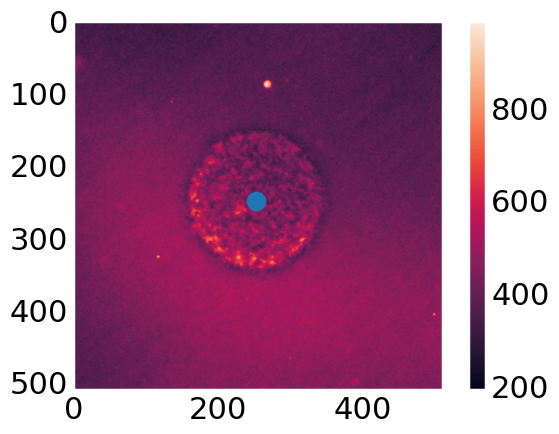

In [21]:
plt.imshow(imagesbs[20])
plt.colorbar()
plt.scatter(allxcent[20], allycent[20])


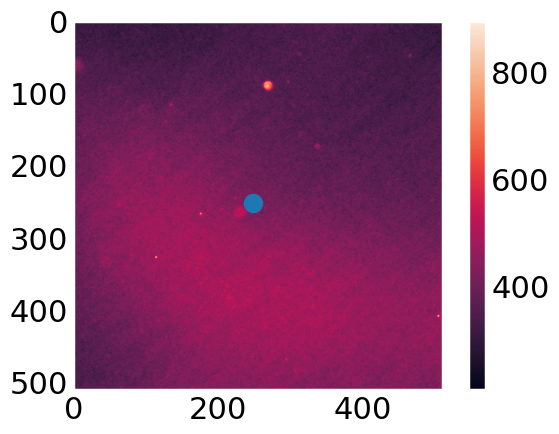

In [23]:
plt.imshow(imagesbs[0])
plt.colorbar()
plt.scatter(allxcent[0], allycent[0])


In [22]:
mask = np.zeros_like(images[0])
for i in range(len(mask)):
    for j in range(len(mask)):
        if ((i-512/2)*umperpx)**2+((j-512/2)*umperpx)**2 < 200**2:
            mask[i,j]=1
mask_coords = np.where(mask.astype(int)) 
allmask_coords = np.s_[:, mask_coords[0], mask_coords[1]]

In [35]:
test = mask*imagesbs[0]
test=test.flatten()
test=test[test>0]
np.median(test), np.mean(test)


(np.float64(431.0), np.float64(431.7174652425562))

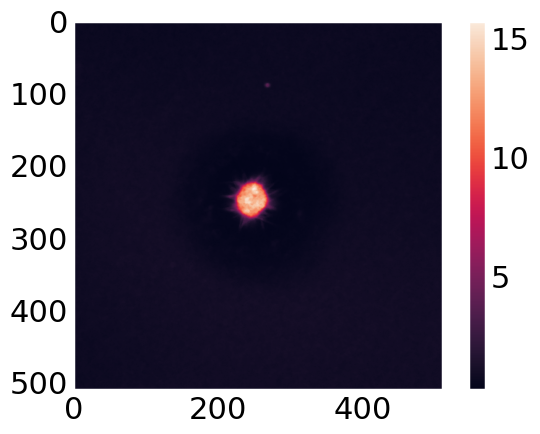

In [42]:
plt.imshow(imagesbs[-1]/431)
plt.colorbar()

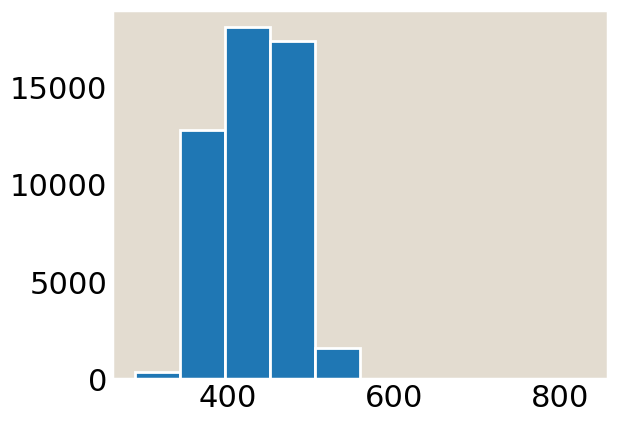

In [34]:
plt.hist((test.flatten())[test.flatten()>0]);

Correct uneven illumination

In [243]:
arrs_norm=norm_unev([imagesbs], mask_coords, allmask_coords)

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2823317895.py:24: RuntimeWarning: divide by zero encountered in divide
  norm_mat = scalar/biv_filt


calibrate to uM units

In [244]:
mt_conc, avg1stMTVal = linear_mt_cal(arrs_norm[0], allmask_coords, returnAvgVal=True)

In [236]:
def makeImFromValsList(valuesList, mask_coords, imshape):
    """ valuesList: numTimepoints x numValues, such that valuesList[t,:] is the list of values we populate in the returned image/array
        mask_coords: tuple of length 2; the first entry is 1d array of rowNums and the second entry is 1d array of colNums, of length = numValues (defined in mask)
        imshape: numImgRows x numImgCols.
        
        Returns imgArrayTotal = (numTimepoints x numImgRows x numImgCols) array where things are zero when outside the mask and otherwise populated by the provided valuesList in appropriate positions.
    """
    imgArrayTotal = np.zeros((len(valuesList), imshape[0], imshape[1]))
    for t in range(len(valuesList)):
        imgArrayTotal[t,mask_coords[0], mask_coords[1]]=valuesList[t,:]
    
    return imgArrayTotal

In [237]:
mtconcImages=makeImFromValsList(mt_conc, mask_coords, (512, 512))

center crop

In [255]:
def find_contour(mask):
    #Find contours of binary image
    contours, heirarchy = cv2.findContours(mask.astype(np.uint8), 1, 2)
    #iterate through contours (for most connected region)
    max_area = 0
    max_index = None
    for j, contour in enumerate(contours):
        area = cv2.contourArea(contour)
        if area > max_area:
            max_area = area
            max_index = j

    #Find the coordinates of the illumination pattern contour
    cnt = contours[max_index]
    cnt = np.array(cnt)
    cnt = np.squeeze(cnt)
    return cnt

In [245]:
def min_radius(mango_mask, centers):
    mango_skin_coords = find_contour(mango_mask)
    #reshapes stuff and broadcasts to do subtraction
    dists = np.sqrt(np.sum((mango_skin_coords[:, np.newaxis, :] - centers[np.newaxis, :, :])**2, axis=2))
    #find the minimum distance
    min_dist = np.min(dists)
    # #find the time and position corresponding to the minimum distance
    # min_dist_point, min_dist_time = np.where(dists==min_dist)
    # #find the coordinate of the minimimum distance
    # min_dist_coord = mango_skin_coords[min_dist_point]
    return min_dist

In [246]:
def centered_crop(arr, centers, min_dist):
    arr_cropped = np.zeros((int(centers.shape[0]), 2*int(min_dist), 2*int(min_dist)))
    
    xmin = (np.round(centers[:, 0]) - int(min_dist)).astype(int)
    xmax = (np.round(centers[:, 0]) + int(min_dist)).astype(int)
    ymin = (np.round(centers[:, 1]) - int(min_dist)).astype(int)
    ymax = (np.round(centers[:, 1]) + int(min_dist)).astype(int)
    for t in range(centers.shape[0]):
        crop = np.s_[ymin[t]:ymax[t], xmin[t]:xmax[t]]
        arr_cropped[t] = arr[t][crop]
        
    
    return arr_cropped

In [256]:
min_dist = min_radius(mask, centers)

In [258]:
mtImsCentCrop = centered_crop(mtconcImages, centers, min_dist)

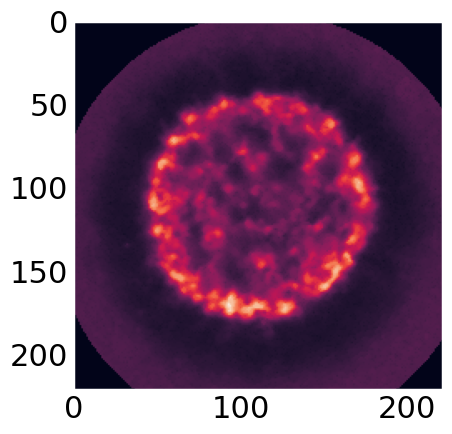

In [259]:
plt.imshow(mtImsCentCrop[40])

radial traces

In [260]:
### hackish binning alternative
## assume square
def cartesianToPolar(image):
    """ Assumes image is a m x m (square, 2d) array, and the origin is the closest-to-central pixel.
        Returns:
            list of all r values of each pixel
    """
    
    m = image.shape[0]
    center = (m // 2, m // 2)
    
    # Create grid of coordinates
    y, x = np.indices((m, m))
    x = x - center[1]
    y = y - center[0]
    
    # Convert to polar coordinates
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    
    return r, theta

def polarAverage(image, bins=20, rTraceMode=np.nanmean):
    r, theta = cartesianToPolar(image)
    
    if type(bins)==int:
        # if just an integer, automatically find the radial bins
        max_radius = np.max(r)
        radial_bins = np.linspace(0, max_radius, bins)
        radial_profile = np.zeros(bins - 1) #preallocate
    
    else:
        # else, if bins is an array, assume that the bin edges are supplied explicitly.
        radial_bins=bins;
        radial_profile = np.zeros(bins.shape[0] - 1)
    
    for i in range(len(radial_bins) - 1):
        mask = (r >= radial_bins[i]) & (r < radial_bins[i + 1])
        radial_profile[i] = rTraceMode(image[mask])
    
    return (radial_bins[:-1]+radial_bins[1:])/2, radial_profile # this returns the MIDPOINT of the radii defining the annuli bins

def getSensibleBins(image, numBins=15):
    rmax=image.shape[0]//2
    return np.linspace(0, rmax, numBins)

In [265]:
numRbins=30
rTraceMode = np.nanmean
# preallocate arrays
all_rMTbins=np.zeros((mtImsCentCrop.shape[0], numRbins-1))
all_rMTavgs=np.zeros((mtImsCentCrop.shape[0], numRbins-1))
for t in range(mtImsCentCrop.shape[0]):
    frame=mtImsCentCrop[t,:,:]
    rbins_thist, radAvgMT_thist= polarAverage(frame, getSensibleBins(frame, numBins=numRbins), rTraceMode=rTraceMode)
    all_rMTbins[t, :]=rbins_thist
    all_rMTavgs

In [270]:
timesMT = np.arange(len(mtImsCentCrop))*5 #s

In [1]:
timesMT

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


NameError: name 'timesMT' is not defined

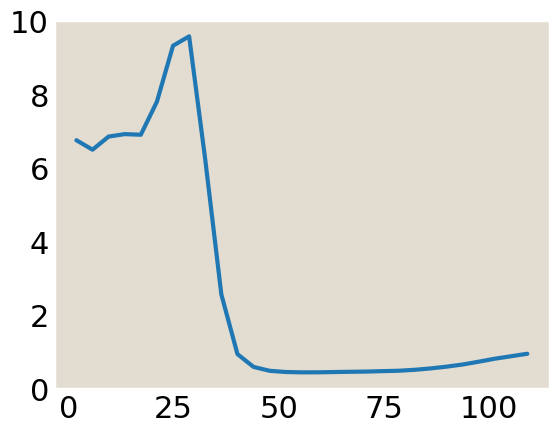

In [268]:
plt.plot(all_rMTbins[100], all_rMTavgs[100])

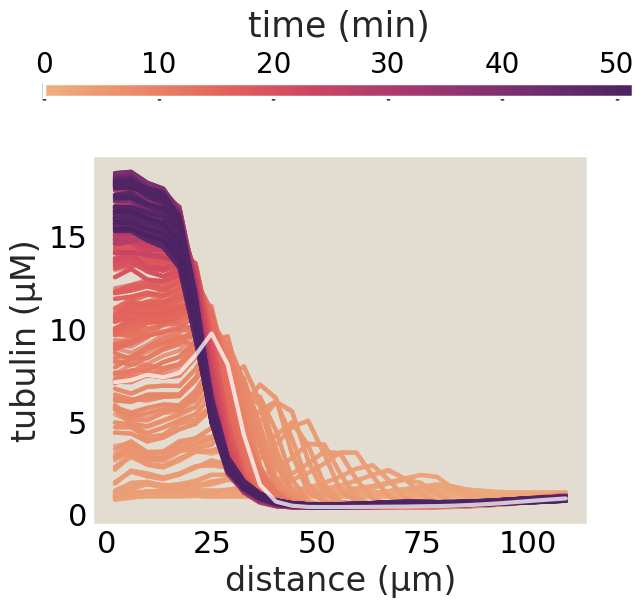

In [329]:
global_timeCmap_MT=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min(timesMT), vmax=max(timesMT))(time))
fig, ax = plt.subplots()
for time in range(all_rMTavgs.shape[0]):
    plt.plot(all_rMTbins[time,:], all_rMTavgs[time,:], alpha=0.75, color=global_timeCmap_MT(timesMT[time]))#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)        
plt.ylabel('tubulin (µM)')
plt.xlabel('distance (µm)')
plt.plot(all_rMTbins[140,:], all_rMTavgs[119,:], alpha=0.75, color='w')#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)        

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # horizontal [left, bottom, width, height]
#cax = fig.add_axes([1, 0.05, 0.03, 0.91])  # vertical [left, bottom, width, height]

# Create the colorbar
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(comsol_time_ls)/60, 
#                                                                  vmax=max(comsol_time_ls)/60)),
#                     cax=cax, orientation='vertical')

# Create an axis for the colorbar that spans all columns
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(timesMT)/60, 
                                                                 vmax=max(timesMT)/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)

1) find max for each time
2) fit sigmoid? to right half
3) fit line? parab? to left half

In [376]:
MTmax = np.max(all_rMTavgs, axis=1)
MTmaxloc = [np.where(all_rMTavgs[i] == MTmax[i])[0] for i in range(len(MTmax))]
MTmaxloc = np.concatenate(MTmaxloc)
MTmaxlocum = MTmaxloc*umperpx

In [354]:
def sigmoid(arr, a, b, c, d):
    return a/(1+np.exp((arr - b)/c)) + d
def fitSigmoid(x, y, p0):
    param,_ = curve_fit(sigmoid, x, y, p0)
    return param

def quadratic(arr, a, b, c, d):
    return a*(arr-d)**2 + b*(arr-d) + c
def fitQuadratic(x, y, p0):
    param,_ = curve_fit(quadratic, x, y, p0)
    return param

def linear(arr, a, b):
    return a*arr + b
def fitLinear(x, y, p0):
    param,_ = curve_fit(linear, x, y, p0)
    return param
    
def exponential(arr, a, b, c):
    return a*np.exp(-arr/b)+c
def fitExponential(x, y, p0):
    param,_ = curve_fit(exponential, x, y, p0)
    return param

peak height

[-3.11580039e-06  8.57419308e-03  1.15634748e+01  8.76255477e+02]


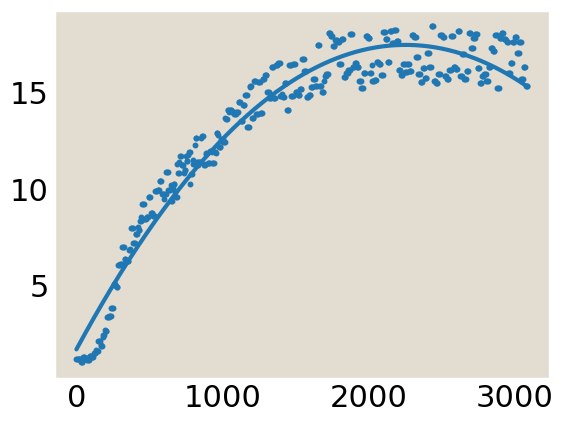

In [359]:
MTmaxfit = fitQuadratic(timesMT, MTmax, [0.5, 1 ,15, 2000])
print(MTmaxfit)
plt.scatter(timesMT, MTmax, s=5)
plt.plot(timesMT, quadratic(timesMT, *MTmaxfit))

[ -43.1921856  -209.46998432  508.70679751   17.03127318]


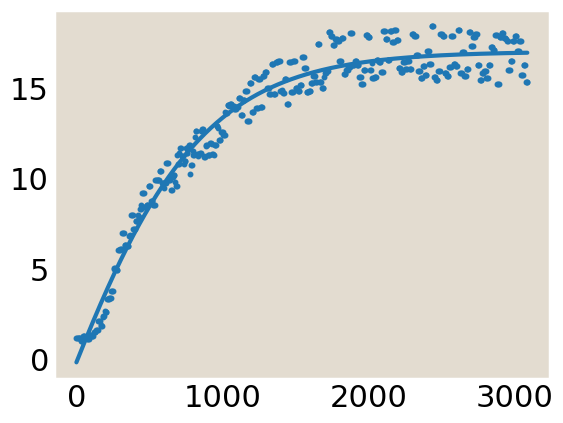

In [603]:
MTmaxfit = fitSigmoid(timesMT, MTmax, [15, 2000, 500, 1])
print(MTmaxfit)
plt.scatter(timesMT, MTmax, s=5)
plt.plot(timesMT, sigmoid(timesMT, *MTmaxfit))

[-18.23648431 666.95695336  17.32635126]


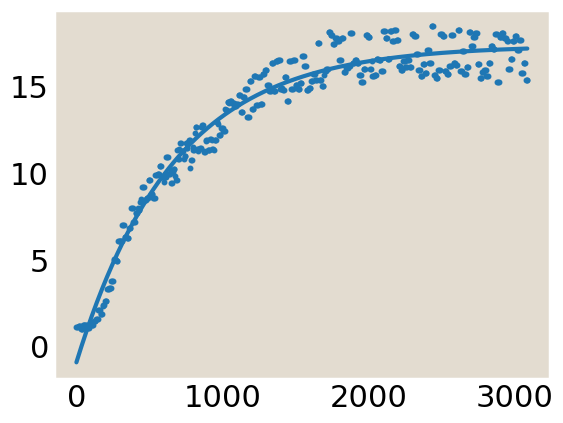

In [619]:
MTmaxfit = fitExponential(timesMT, MTmax, [-15, 500, 15])
print(MTmaxfit)
plt.scatter(timesMT, MTmax, s=5)
plt.plot(timesMT, exponential(timesMT, *MTmaxfit))

peak location

[ 31.79737578 475.15606561   0.50040255]


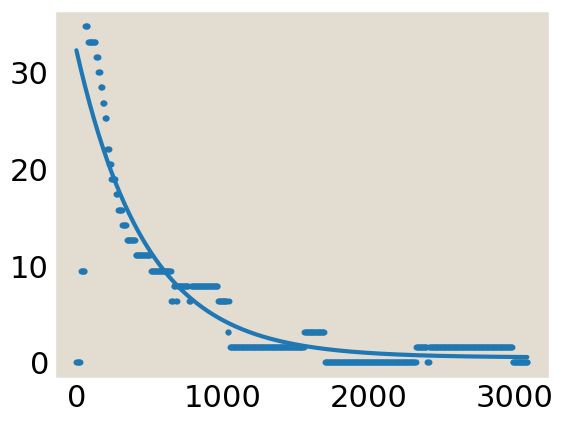

In [618]:
MTmaxlocfit = fitExponential(timesMT[6:], MTmaxlocum[6:], [35, 400, 1])
print(MTmaxlocfit)
plt.plot(timesMT, exponential(timesMT, *MTmaxlocfit))
plt.scatter(timesMT, MTmaxlocum, s=5)

x=0 anchor point

[-20.4021281  806.98182575  17.96830263]


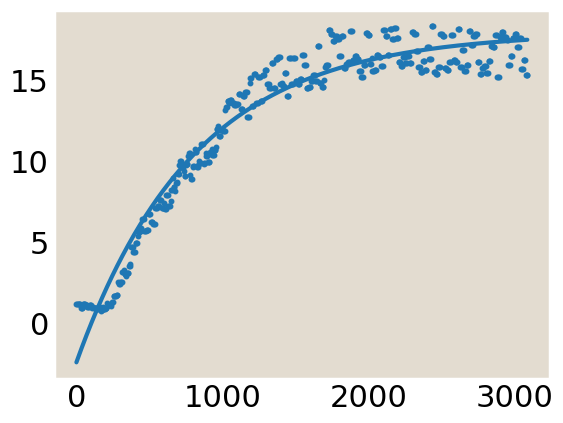

In [397]:
MTx0fit = fitExponential(timesMT,all_rMTavgs[:,0], [-15, 1000, 15])
print(MTx0fit)
plt.plot(timesMT, exponential(timesMT, *MTx0fit))
plt.scatter(timesMT, all_rMTavgs[:,0], s=5)

[-24.64547175 617.2580981   17.32786614]


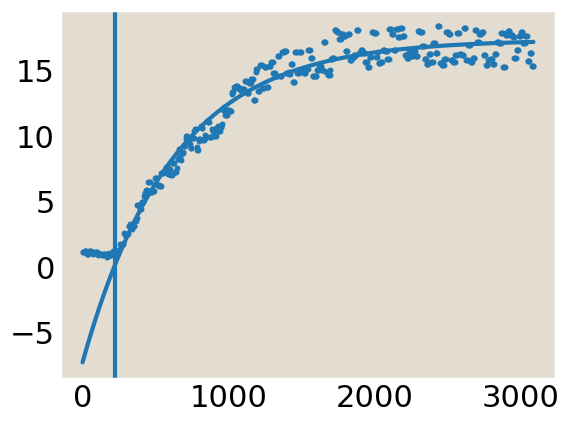

In [401]:
MTx0fit = fitExponential(timesMT[45:],all_rMTavgs[45:,0], [-15, 1000, 15])
print(MTx0fit)
plt.plot(timesMT, exponential(timesMT, *MTx0fit))
plt.scatter(timesMT, all_rMTavgs[:,0], s=5)
plt.axvline(timesMT[45])

[-19.68409901 582.77624775 333.29838743  16.8052189 ]


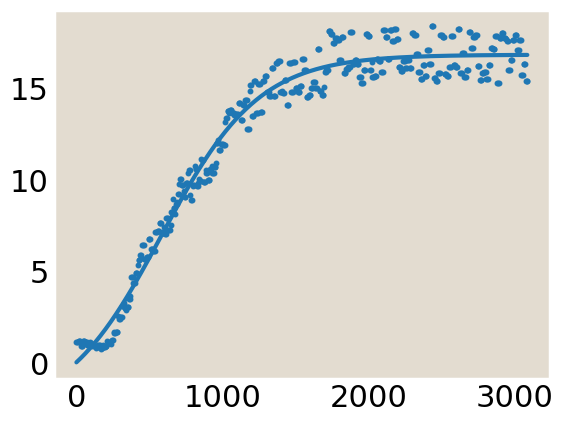

In [403]:
MTx0fit = fitSigmoid(timesMT,all_rMTavgs[:,0], [15, 1000, 1000, 1])
print(MTx0fit)
plt.plot(timesMT, sigmoid(timesMT, *MTx0fit))
plt.scatter(timesMT, all_rMTavgs[:,0], s=5)

In [614]:
def crazyftn(arr, a, b, c, d, g, h):
    right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
    left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
    return right+left

def fitcrazyftn(x, y, p0):
    param,_ = curve_fit(crazyftn, x, y, p0)
    return param, _

26.388064277726873 10.069764167841676 52.77739768635355 0.5578230297682671 7.261030049190251 32.124445834843534


/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2616787162.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2616787162.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2616787162.py:3: RuntimeWarning: invalid value encountered in multiply
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)


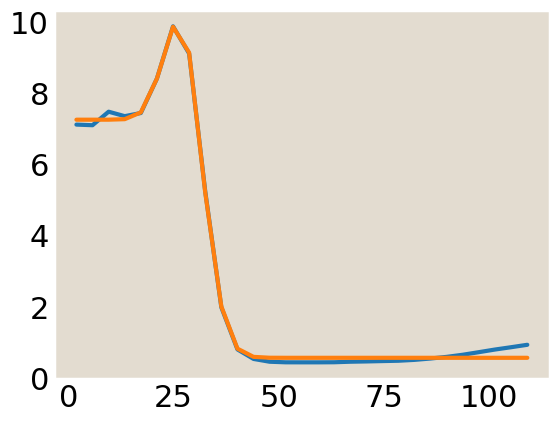

In [568]:
i=95+14
plt.plot(all_rMTbins[i], all_rMTavgs[i])
plt.plot(all_rMTbins[i,:], crazyftn(all_rMTbins[i,:], 
                                    *fitcrazyftn(all_rMTbins[i,:], 
                                                 all_rMTavgs[i,:], 
                                                 [exponential(timesMT[i], *MTmaxlocfit), exponential(timesMT[i], *MTmaxfit), 5, 1.1, sigmoid(timesMT[i], *MTx0fit), 5])))
print(*fitcrazyftn(all_rMTbins[i,:], all_rMTavgs[i,:],[exponential(timesMT[i], *MTmaxlocfit), exponential(timesMT[i], *MTmaxfit), 5, 1.1, sigmoid(timesMT[i], *MTx0fit), 5]))

In [525]:
def crazyftn_redu(arr, c, d, h):
    a = exponential(arr, *MTmaxlocfit)
    b = exponential(arr, *MTmaxfit)
    g = sigmoid(arr, *MTx0fit)
    right = (1/(1+np.exp(-100*(arr-a)))) * ((b- d)*np.exp(-(arr-a)**2/c) + d)
    left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
    return right+left

def fitcrazyftn_redu(x, y, p0):
    param,_ = curve_fit(crazyftn_redu, x, y, p0)
    return param

In [569]:
fits_redu = []
fittedindex_redu = []
for i in tqdm(np.arange(len(all_rMTavgs))):
    try:
        # your code that might fail
        fit = fitcrazyftn_redu(all_rMTbins[i,:], all_rMTavgs[i,:], [5, 1.1, 5]) #[25, 10, 5, 1.1, 7, 5]
        fits_redu.append(fit)
        fittedindex_redu.append(i)
    except RuntimeError as e:
        print(f"Skipping {i} due to error: {e}")
        continue

  0%|          | 0/618 [00:00<?, ?it/s]

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/832608502.py:5: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b- d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/832608502.py:6: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/832608502.py:6: RuntimeWarning: invalid value encountered in multiply
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/832608502.py:10: OptimizeWarning: Covariance of the parameters could not be estimated
  param,_ = curve_fit(crazyftn_redu, x, y, p0)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/832608502.py:5: RuntimeWarning: invalid value encountered in multiply
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b- d)*np.exp(-(arr-a)**2/c) + d)


0.2287819052676183


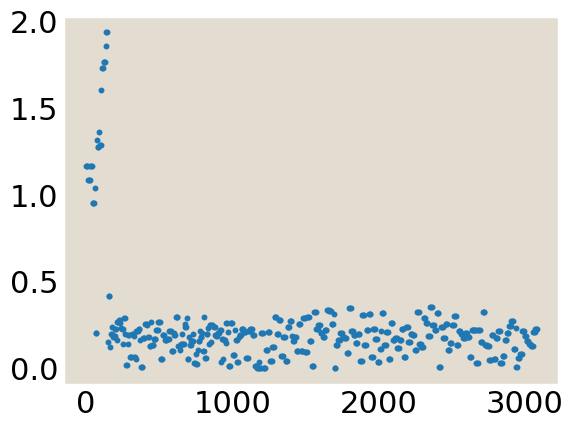

In [570]:
print(np.average(np.array(fits_redu)[:, 0]))
plt.scatter(timesMT, np.array(fits_redu)[:, 0], s=5)

0.7357641038401307


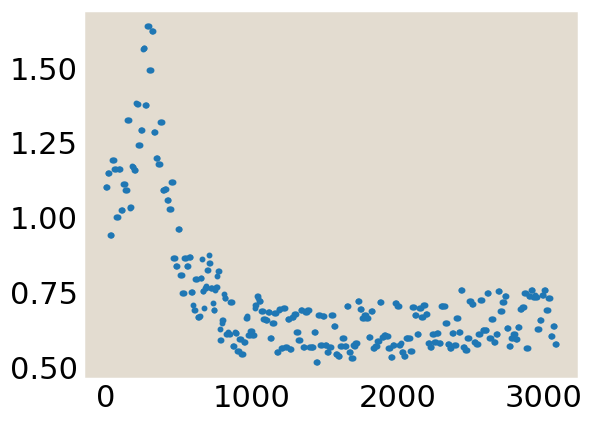

In [571]:
print(np.average(np.array(fits_redu)[:, 1]))
plt.scatter(timesMT, np.array(fits_redu)[:, 1], s=5)

0.09969447644176314


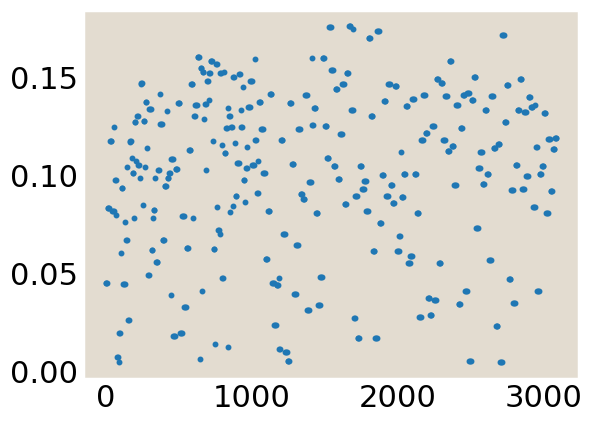

In [572]:
print(np.average(np.array(fits_redu)[:, 2]))
plt.scatter(timesMT, np.array(fits_redu)[:, 2], s=5)

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/832608502.py:5: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b- d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/832608502.py:6: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/665323040.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


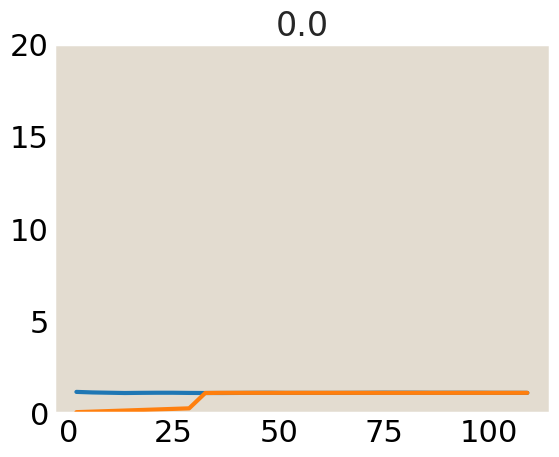

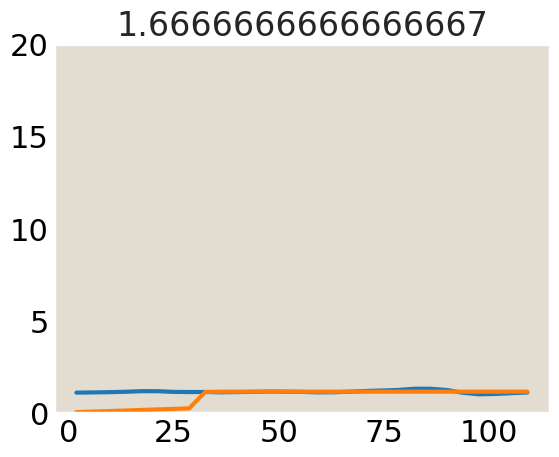

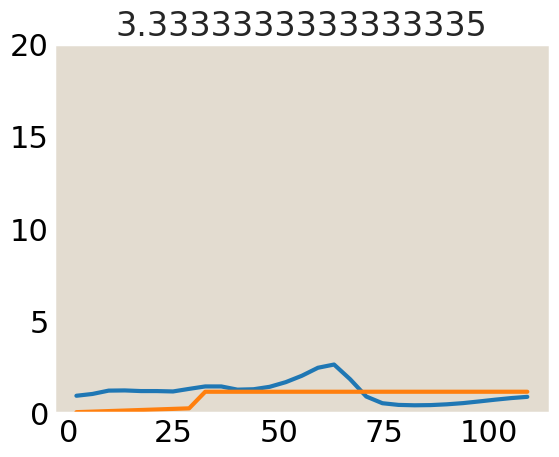

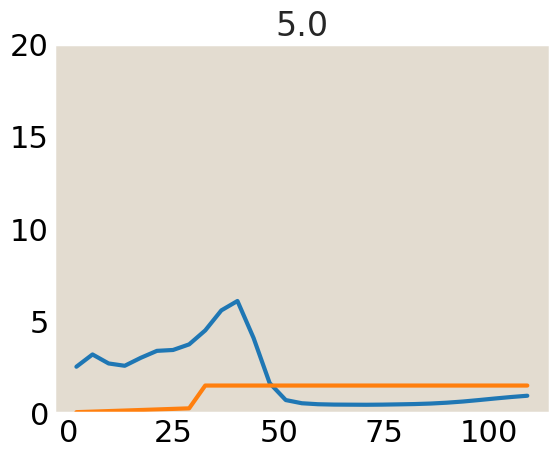

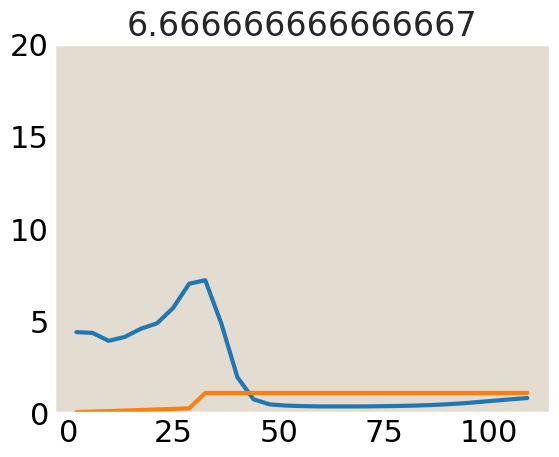

...

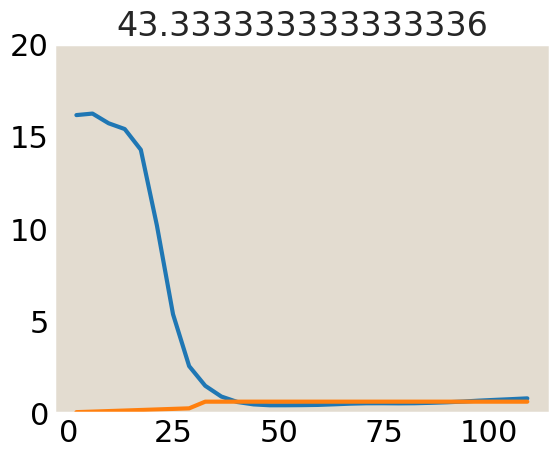

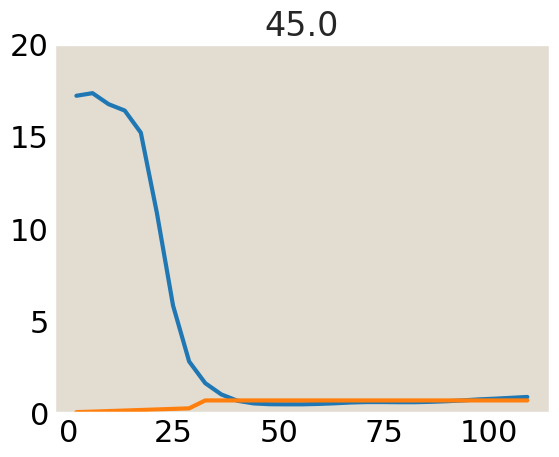

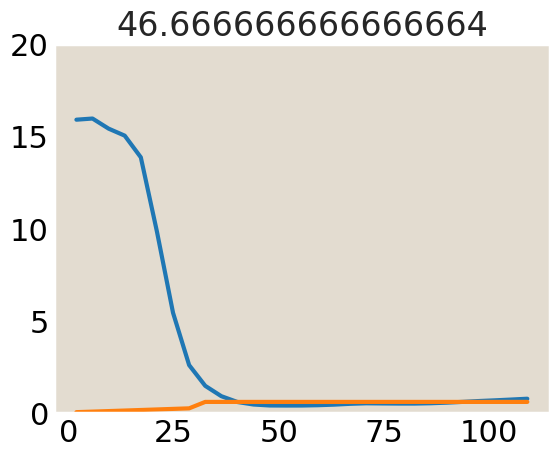

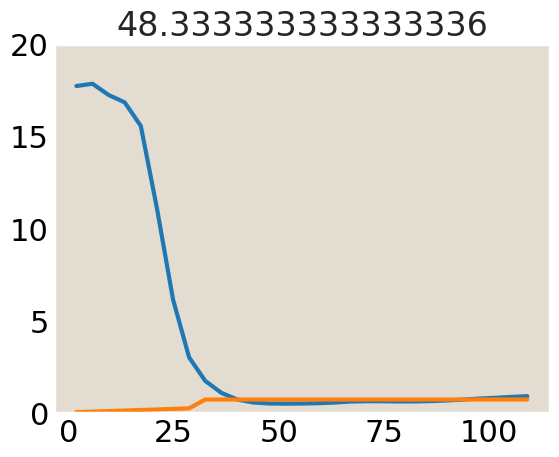

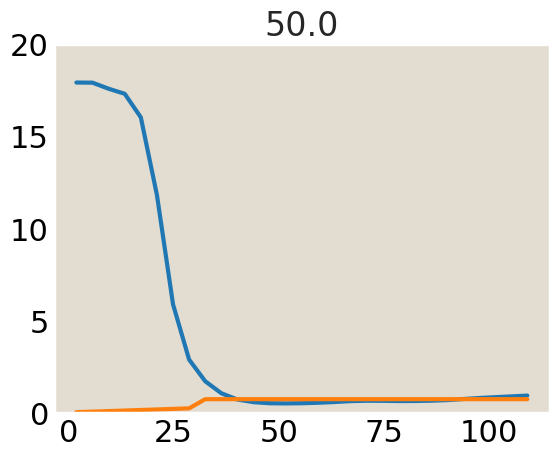

In [583]:
for i in np.arange(0, 618, 20):#len(all_rMTavgs)):
    fig, ax = plt.subplots()
    ax.plot(all_rMTbins[i], all_rMTavgs[i])
    ax.plot(all_rMTbins[i,:], crazyftn_redu(all_rMTbins[i,:], *fits_redu[i]))
    #plt.scatter(all_rMTbins[i][MTmaxloc[i]], MTmax[i], c='k', s=10)
    ax.set_title(timesMT[i]/60)
    ax.set_ylim(0, 20)

# full crazy ftn

In [646]:
fits = []
fittedindex = []
cov = []
ssr = []
for i in tqdm(np.arange(len(all_rMTavgs))):
    try:
        # your code that might fail
        fit, cov_ = fitcrazyftn(all_rMTbins[i,:], all_rMTavgs[i,:], [exponential(timesMT[i], *MTmaxlocfit), exponential(timesMT[i], *MTmaxfit), 5, 1.1, sigmoid(timesMT[i], *MTx0fit), 5]) #[25, 10, 5, 1.1, 7, 5]
        fits.append(fit)
        fittedindex.append(i)
        cov.append(cov_)
        ssr.append(np.sum((all_rMTavgs[i] - crazyftn(all_rMTbins[i,:], *fit))**2))
    except RuntimeError as e:
        print(f"Skipping {i} due to error: {e}")
        continue
        

  0%|          | 0/618 [00:00<?, ?it/s]

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: invalid value encountered in multiply
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: invalid value encountered in multiply
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  param,_ = curve_fit(crazyftn, x, y, p0)
/home/aduarte/am_atp/analysis/aster/ipyker

Skipping 94 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.
Skipping 108 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.
Skipping 110 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.
Skipping 117 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.
Skipping 302 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.
Skipping 303 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.
Skipping 304 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.
Skipping 305 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.


(-5.0, 40.0)

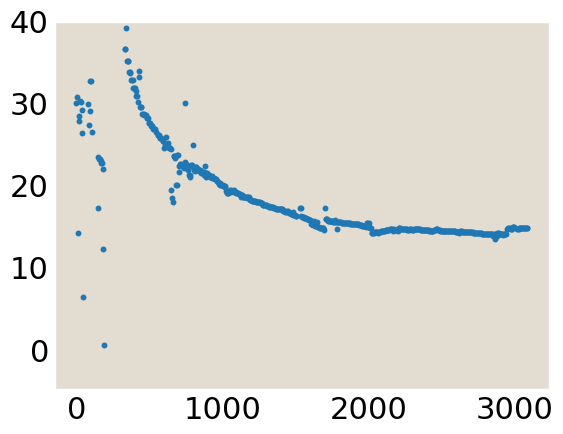

In [645]:
plt.scatter(timesMT[fittedindex], np.array(fits)[:,0], s=5)
plt.ylim(-5, 40)

0.0004200069815393089
0.000554636006830593


/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)


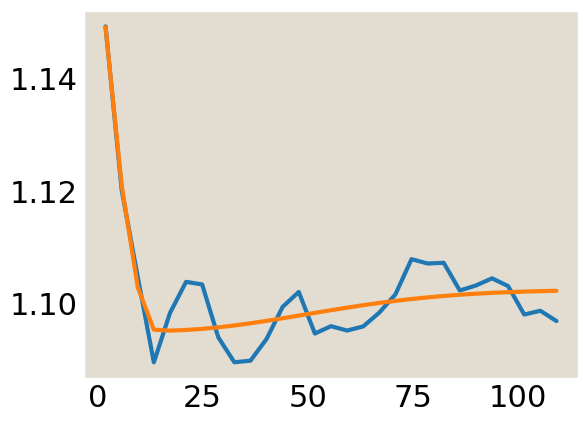

In [660]:
i=2
plt.plot(all_rMTbins[i], all_rMTavgs[i])
plt.plot(all_rMTbins[i,:], crazyftn(all_rMTbins[i,:], *fits[i]))
print(np.sum(((all_rMTavgs[i]-crazyftn(all_rMTbins[i,:], *fits[i]))/max(crazyftn(all_rMTbins[i,:], *fits[i])))**2))
print(ssr[i])                                    

a - peak location

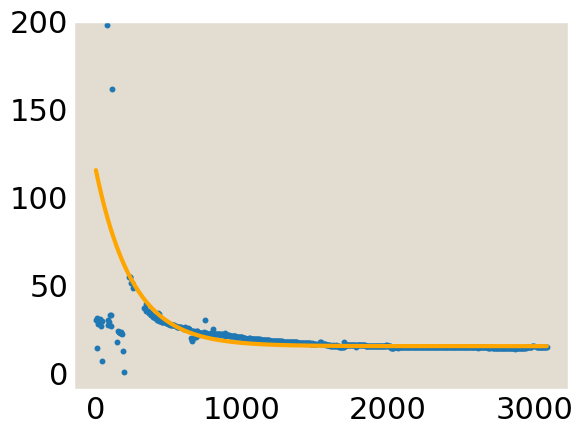

In [1360]:
plt.scatter(timesMT[fittedindex], np.array(fits)[:,0], s=5)
plt.ylim(-10, 200)
MTmaxlocfit2 = fitExponential(timesMT[fittedindex], np.array(fits)[:,0], [35, 400, 1])
#print(MTmaxlocfit2)
#plt.plot(timesMT, exponential(timesMT, *MTmaxlocfit2))
#plt.plot(timesMT, exponential(timesMT, *MTmaxlocfit))
plt.plot(timesMT, exponential(timesMT, 100, 250, 15), color='orange')

[140.60311272  95.94590785   5.72806132]


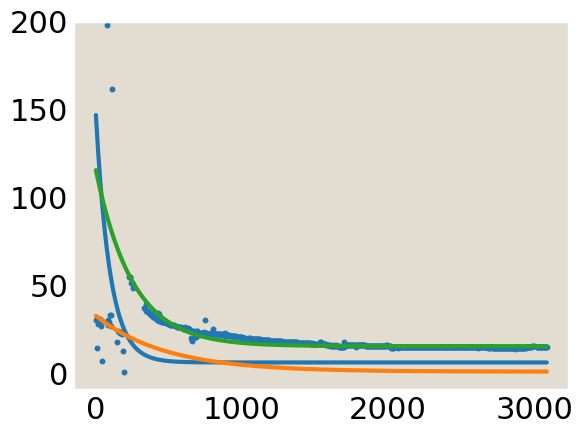

In [681]:
plt.scatter(timesMT[fittedindex], np.array(fits)[:,0], s=5)
plt.ylim(-10, 200)
MTmaxlocfit2 = fitExponential(timesMT[fittedindex], np.array(fits)[:,0], [35, 400, 1])
print(MTmaxlocfit2)
plt.plot(timesMT, exponential(timesMT, *MTmaxlocfit2))
plt.plot(timesMT, exponential(timesMT, *MTmaxlocfit))
plt.plot(timesMT, exponential(timesMT, 100, 250, 15))

In [742]:
np.where(exponential(timesMT, 100, 250, 15)<0)

(array([], dtype=int64),)

b - peak height

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/865711499.py:2: RuntimeWarning: overflow encountered in exp
  return a/(1+np.exp((arr - b)/c)) + d
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/865711499.py:4: OptimizeWarning: Covariance of the parameters could not be estimated
  param,_ = curve_fit(sigmoid, x, y, p0)


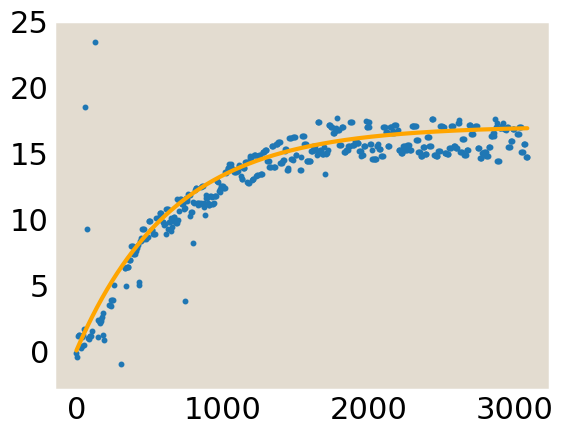

In [1361]:
plt.scatter(timesMT[fittedindex], np.array(fits)[:,1], s=5)
plt.ylim(-3, 25)
MTmaxfit2 = fitSigmoid(timesMT[fittedindex], np.array(fits)[:,1], [-43, -209, 508, 17])
#print(MTmaxfit2)
#plt.plot(timesMT, sigmoid(timesMT, *MTmaxfit2))
#plt.plot(timesMT, sigmoid(timesMT, -35, -100, 500, 16))
plt.plot(timesMT, exponential(timesMT, -17, 660, 17), color='orange')
#plt.plot(timesMT[fittedindex],  np.array(fits)[:,1])
# plt.axhline(0)
# plt.axvline(0)

In [765]:
np.where(exponential(timesMT, -17, 660, 17)<0)

(array([], dtype=int64),)

c - right sigmoid param

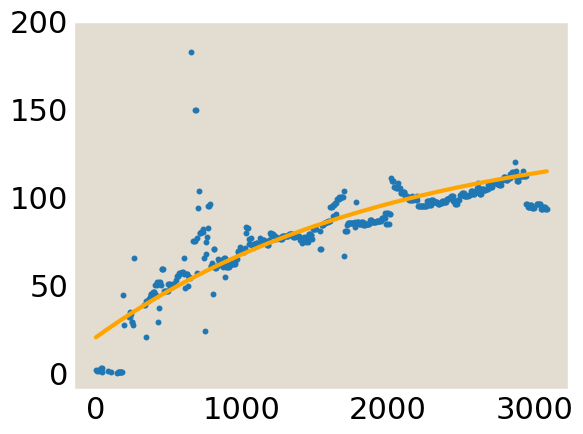

In [1362]:
plt.scatter(timesMT[fittedindex], np.array(fits)[:,2], s=5)
plt.ylim(-10, 200)
plt.plot(timesMT, exponential(timesMT, -120, 2000, 140), color='orange')

In [744]:
np.where(exponential(timesMT, -120, 2000, 140)<0)

(array([], dtype=int64),)

d - base level concentration of tubulin

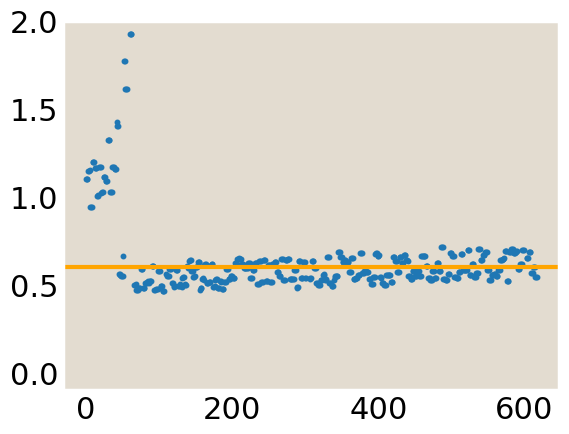

In [1363]:
plt.scatter(fittedindex, np.array(fits)[:,3], s=5)
plt.ylim(-0.1, 2)
plt.axhline(0.6, color='orange')

g - x=0 height

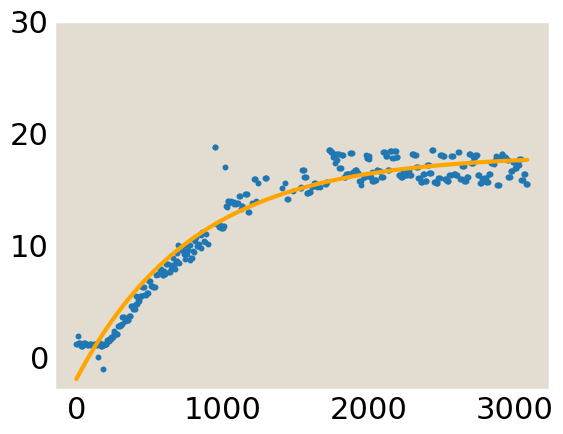

In [1364]:
plt.scatter(timesMT[fittedindex], np.array(fits)[:,4], s=5)
plt.ylim(-3, 30)
#plt.plot(timesMT, exponential(timesMT, -18, 820, 18), color='orange')
plt.plot(timesMT, exponential(timesMT, -20, 807, 18), color='orange')
# plt.axhline(0)
# plt.axvline(0)

In [746]:
np.where(exponential(timesMT, -20, 807, 18)<0)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17]),)

h - left sigmoid parameter

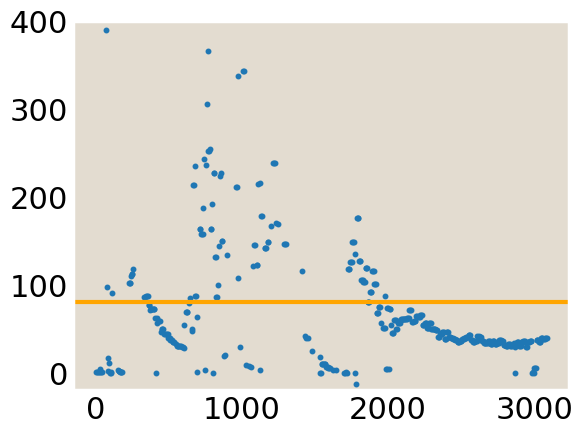

In [1365]:
plt.scatter(timesMT[fittedindex], np.array(fits)[:,5], s=5)
plt.ylim(-20, 400)
plt.axhline(80, color='orange')

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/326050798.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


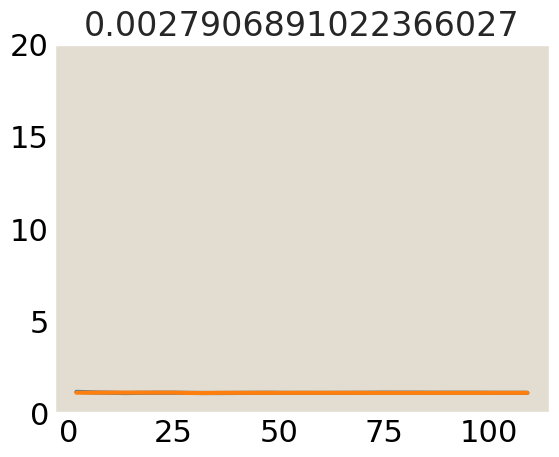

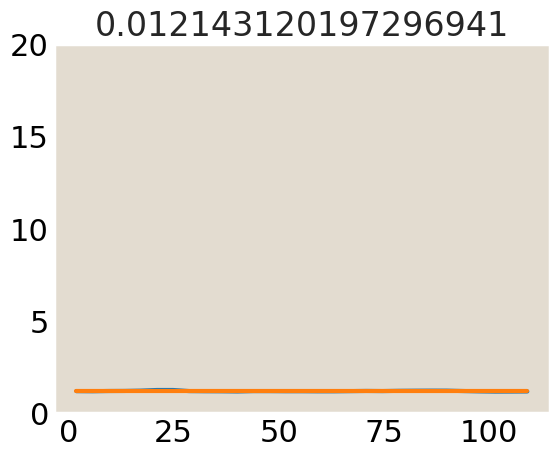

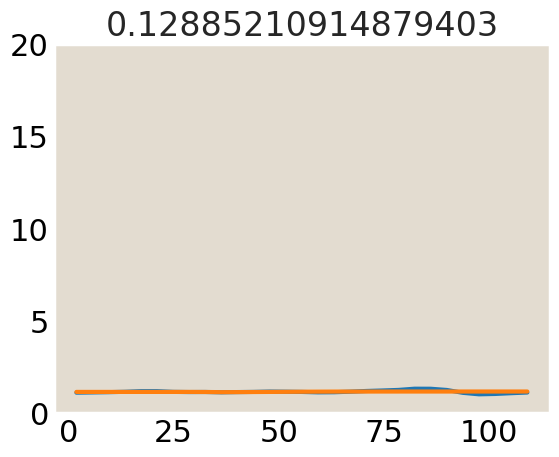

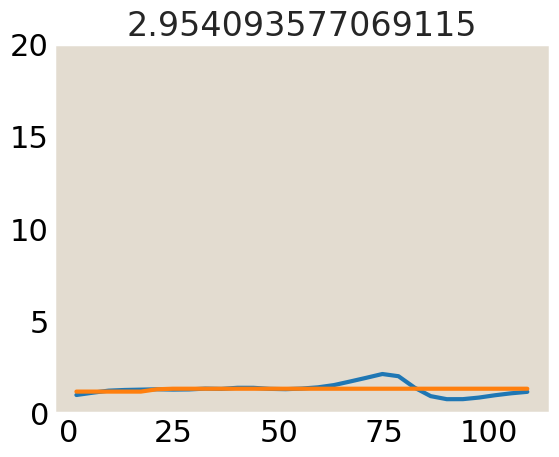

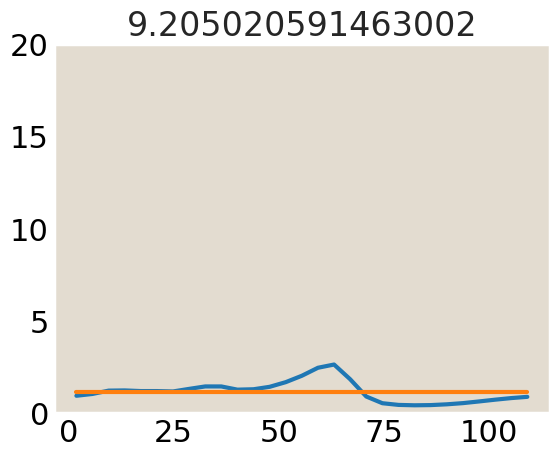

...

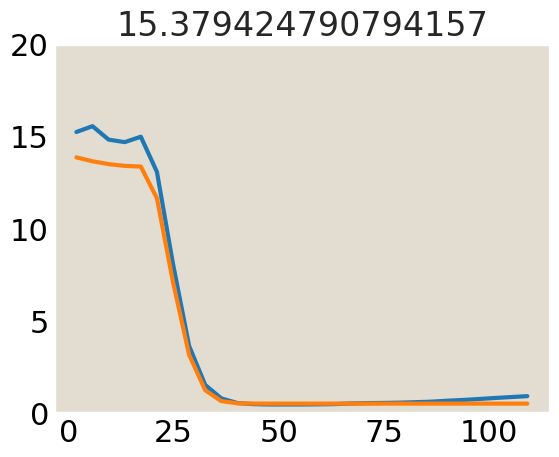

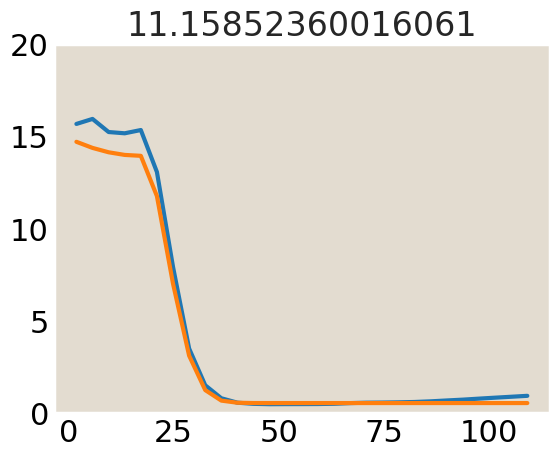

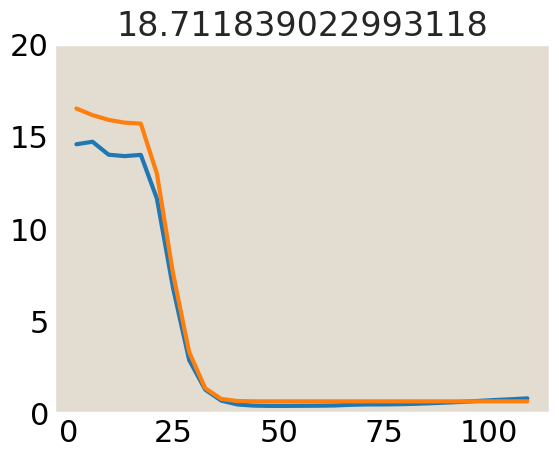

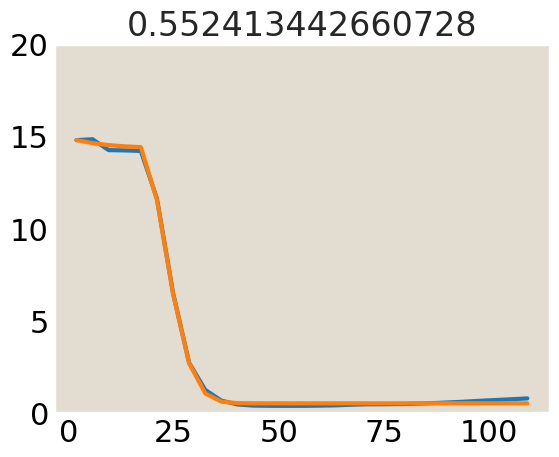

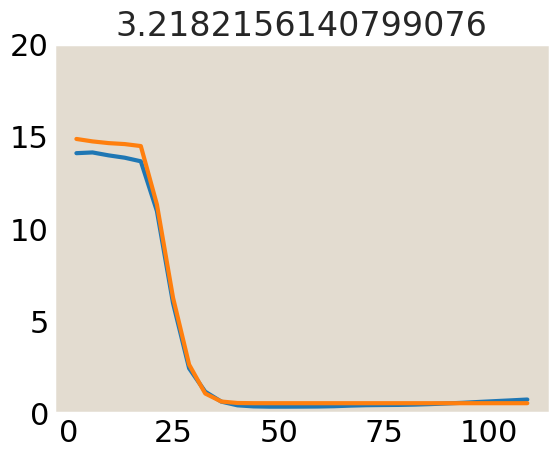

In [636]:
for i in np.arange(0, 300, 10):#len(all_rMTavgs)):
    fig, ax = plt.subplots()
    ax.plot(all_rMTbins[i], all_rMTavgs[i])
    fitcurveplot = crazyftn(all_rMTbins[i,:], *fits[i])
    ax.plot(all_rMTbins[i,:], fitcurveplot)
    #plt.scatter(all_rMTbins[i][MTmaxloc[i]], MTmax[i], c='k', s=10)
    ax.set_title(np.sum((all_rMTavgs[i] - fitcurveplot)**2))
    ax.set_ylim(0, 20)

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/3491285763.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


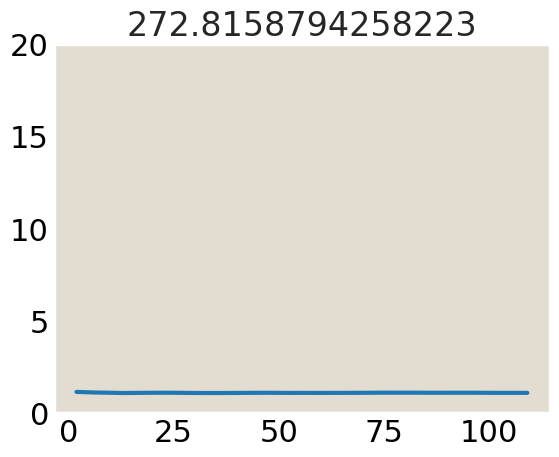

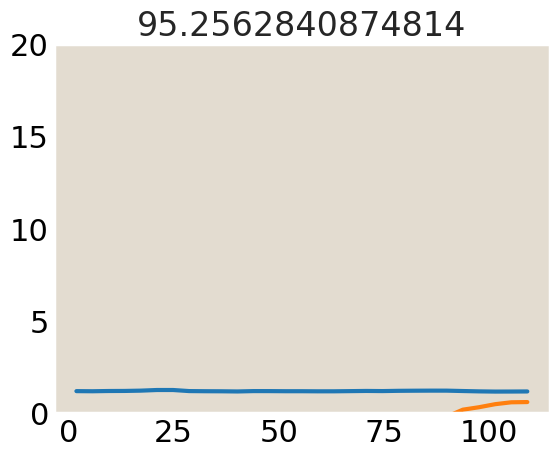

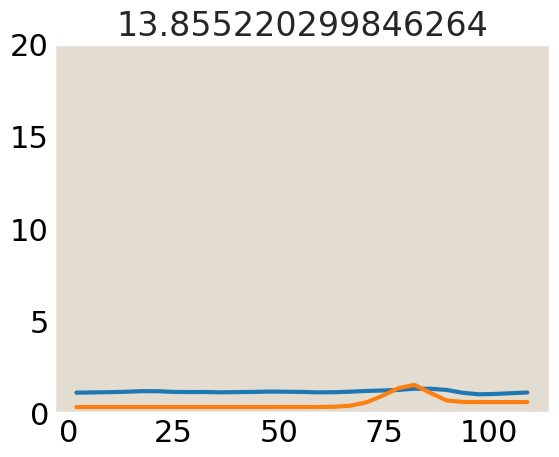

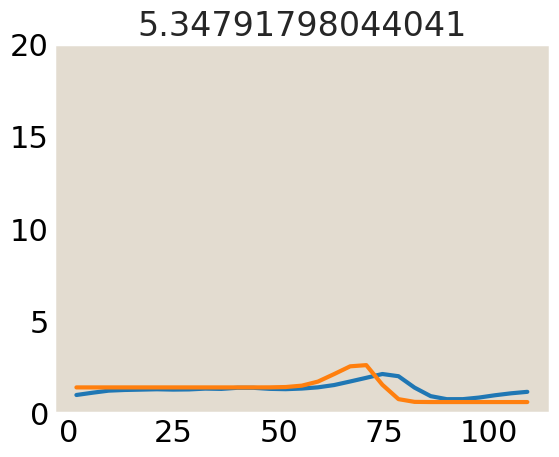

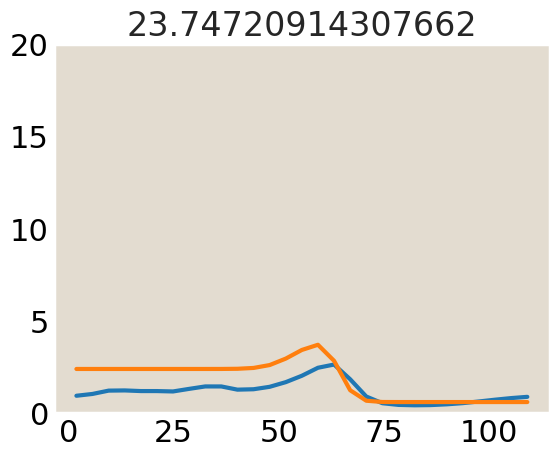

...

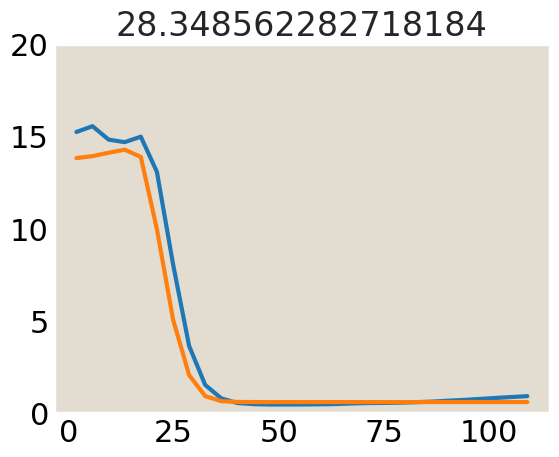

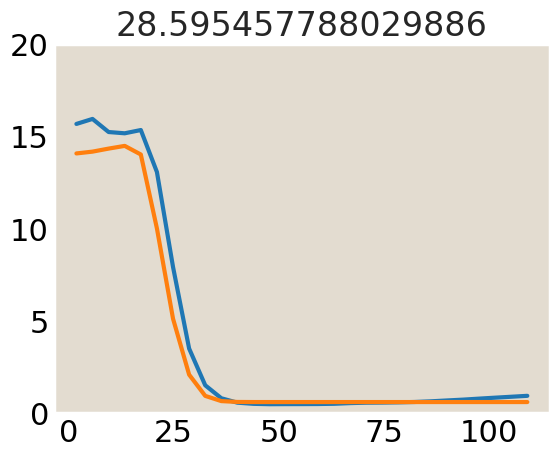

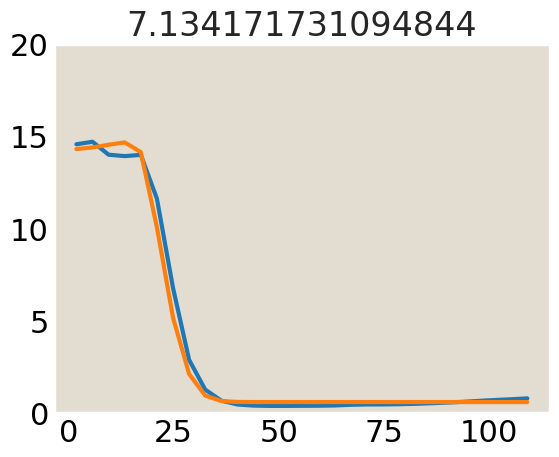

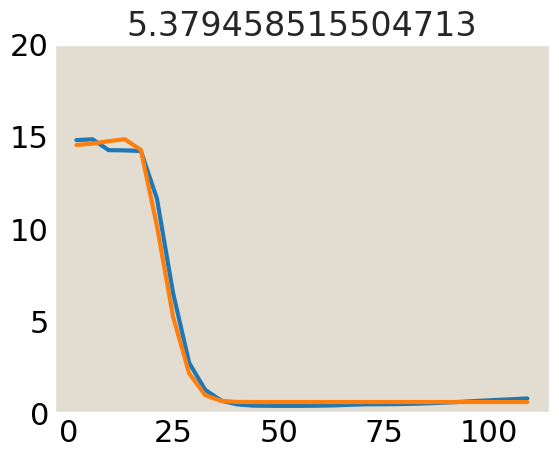

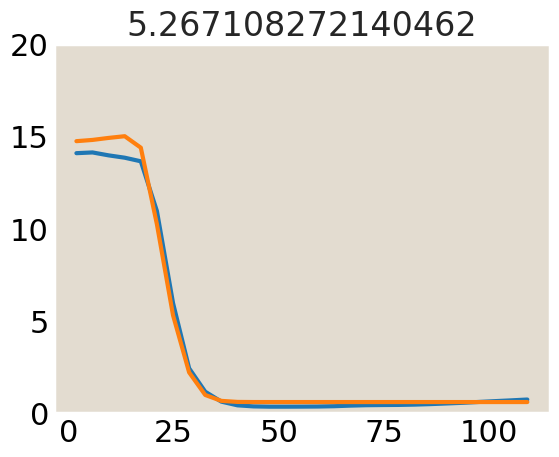

In [727]:
for i in np.arange(0, 300, 10):#len(all_rMTavgs)):
    fig, ax = plt.subplots()
    ax.plot(all_rMTbins[i], all_rMTavgs[i])
    a = exponential(timesMT, 100, 250, 15)
    b = exponential(timesMT, -18, 660, 17)
    c = exponential(timesMT, -120, 2000, 140)
    d = 0.6
    g = exponential(timesMT, -20, 807, 18)
    h = 80
    fitcurveplot = crazyftn(all_rMTbins[i,:], a[i], b[i], c[i], d, g[i], h)
    ax.plot(all_rMTbins[i,:], fitcurveplot)
    #plt.scatter(all_rMTbins[i][MTmaxloc[i]], MTmax[i], c='k', s=10)
    ax.set_title(np.sum((all_rMTavgs[i] - fitcurveplot)**2))
    ax.set_ylim(0, 20)

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)


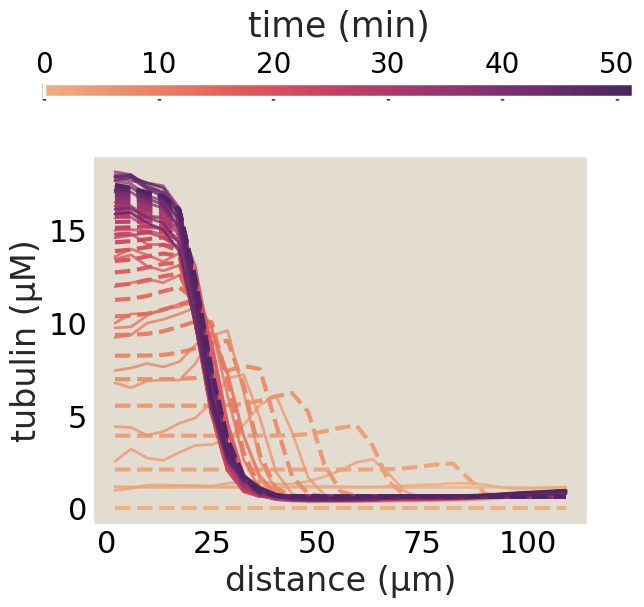

In [772]:
global_timeCmap_MT=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min(timesMT), vmax=max(timesMT))(time))
fig, ax = plt.subplots()

#a = exponential(timesMT, 32, 475, 0.5)
a = exponential(timesMT, 100, 250, 15)
#b = exponential(timesMT, -18.23648431, 666.95695336,  17.32635126)
b = exponential(timesMT, -17, 660, 17)#-18, 660, 17)
c = exponential(timesMT, -120, 2000, 140)
d = 0.6
g = exponential(timesMT,  -18, 820, 18)#-20, 807, 18)
#g = exponential(timesMT, -24.64547175, 617.2580981,   17.32786614)
h = 80

for time in range(all_rMTavgs.shape[0]):
    if time%20==0:
        plt.plot(all_rMTbins[time,:], all_rMTavgs[time,:], alpha=0.75, color=global_timeCmap_MT(timesMT[time]), lw=2)#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)   
        plt.plot(all_rMTbins[time,:], crazyftn(all_rMTbins[time,:], a[time], b[time], c[time], d, g[time], h), ls='--', color=global_timeCmap_MT(timesMT[time]))
plt.ylabel('tubulin (µM)')
plt.xlabel('distance (µm)')
#plt.ylim(0,20)
# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # horizontal [left, bottom, width, height]
#cax = fig.add_axes([1, 0.05, 0.03, 0.91])  # vertical [left, bottom, width, height]

# Create the colorbar
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(comsol_time_ls)/60, 
#                                                                  vmax=max(comsol_time_ls)/60)),
#                     cax=cax, orientation='vertical')

# Create an axis for the colorbar that spans all columns
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(timesMT)/60, 
                                                                 vmax=max(timesMT)/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)


/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)


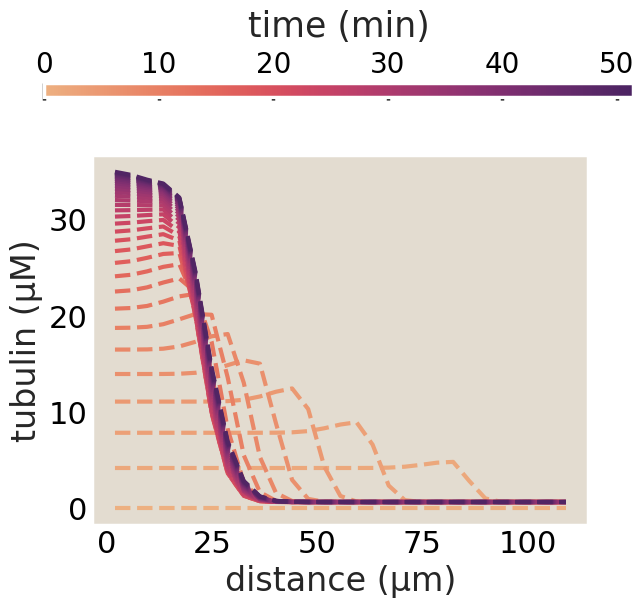

In [1271]:
global_timeCmap_MT=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min(timesMT), vmax=max(timesMT))(time))
fig, ax = plt.subplots()

#a = exponential(timesMT, 32, 475, 0.5)
a = exponential(timesMT, 100, 250, 15)
#b = exponential(timesMT, -18.23648431, 666.95695336,  17.32635126)
b = 2*exponential(timesMT, -17, 660, 17)#-18, 660, 17)
c = exponential(timesMT, -120, 2000, 140)
d = 0.6
g = 2*exponential(timesMT,  -18, 820, 18)#-20, 807, 18)
#g = exponential(timesMT, -24.64547175, 617.2580981,   17.32786614)
h = 80

for time in range(all_rMTavgs.shape[0]):
    if time%20==0:
        #plt.plot(all_rMTbins[time,:], all_rMTavgs[time,:], alpha=0.75, color=global_timeCmap_MT(timesMT[time]), lw=2)#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)   
        plt.plot(all_rMTbins[time,:], crazyftn(all_rMTbins[time,:], a[time], b[time], c[time], d, g[time], h), ls='--', color=global_timeCmap_MT(timesMT[time]))
plt.ylabel('tubulin (µM)')
plt.xlabel('distance (µm)')
#plt.ylim(0,20)
# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # horizontal [left, bottom, width, height]
#cax = fig.add_axes([1, 0.05, 0.03, 0.91])  # vertical [left, bottom, width, height]

# Create the colorbar
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(comsol_time_ls)/60, 
#                                                                  vmax=max(comsol_time_ls)/60)),
#                     cax=cax, orientation='vertical')

# Create an axis for the colorbar that spans all columns
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(timesMT)/60, 
                                                                 vmax=max(timesMT)/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)


In [333]:
fit119 = fitcrazyftn(all_rMTbins[119,:], all_rMTavgs[119,:], [25, 10, 5, 1.1, 7, 5])

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2616787162.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2616787162.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2616787162.py:3: RuntimeWarning: invalid value encountered in multiply
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)


/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2616787162.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2616787162.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)


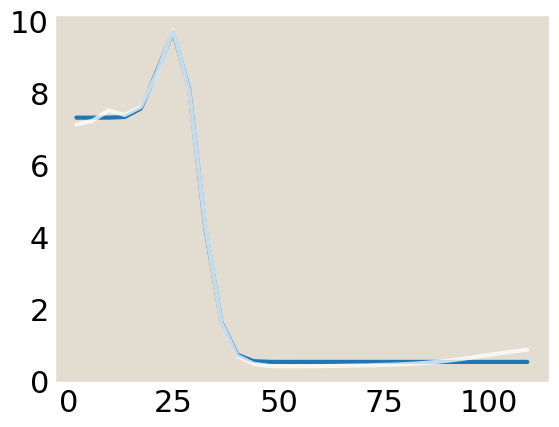

In [337]:
plt.plot(all_rMTbins[119,:], crazyftn(all_rMTbins[119,:], *fit119))
plt.plot(all_rMTbins[140,:], all_rMTavgs[119,:], alpha=0.75, color='w')#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)        


In [287]:
def sigmoid(arr, a, b, c, d):
    return a/(1+np.exp((arr - b)/c)) + d
def fitSigmoid(x, y, p0):
    param,_ = curve_fit(sigmoid, x, y, p0)
    return param

def quadratic(arr, a, b, c):
    return a*arr**2 + b*arr + c
def fitQuadratic(x, y, p0):
    param,_ = curve_fit(quadratic, x, y, p0)
    return param

def linear(arr, a, b):
    return a*arr + b
def fitLinear(x, y, p0):
    param,_ = curve_fit(linear, x, y, p0)
    return param
    
def exponential(arr, a, b, c):
    return a*np.exp(-arr/b)+c
def fitExponential(x, y, p0):
    param,_ = curve_fit(exponential, x, y, p0)
    return param

In [291]:
sigParams=[]
for t in np.arange(all_rMTbins.shape[0]):
    sigParams.append(fitSigmoid(all_rMTbins[t]*umperpx, all_rMTavgs[t], [all_rMTavgs[t].max()-all_rMTavgs[t].min(), 150-0.5*t, 1, all_rMTavgs[t].min()]))
sigParams=np.array(sigParams)

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/3860553581.py:2: RuntimeWarning: overflow encountered in exp
  return a/(1+np.exp((arr - b)/c)) + d
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/3860553581.py:4: OptimizeWarning: Covariance of the parameters could not be estimated
  param,_ = curve_fit(sigmoid, x, y, p0)


RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.

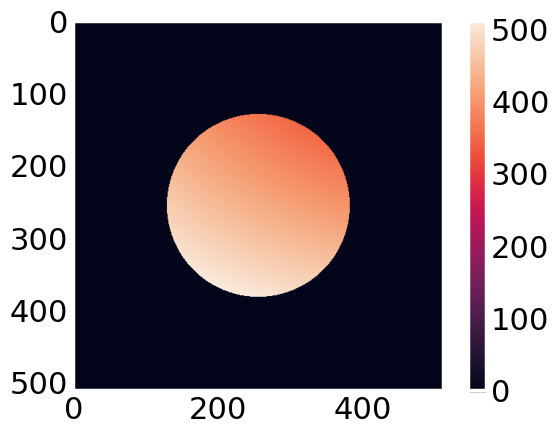

In [230]:
blank = np.zeros_like(imagesbs[0])
temp=evaluateBivPoly_anyShape(imagesbs[0, :, :][mask_coords], mask_coords)
blank[mask_coords]=temp#-min(temp)
plt.imshow(blank)
plt.colorbar()

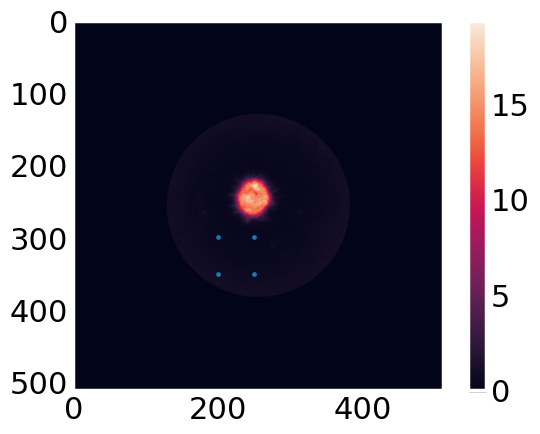

In [238]:
plt.imshow(mtconcImages[300])
plt.colorbar()
plt.scatter([200, 250, 200, 250],[300, 300, 350, 350], s=2)

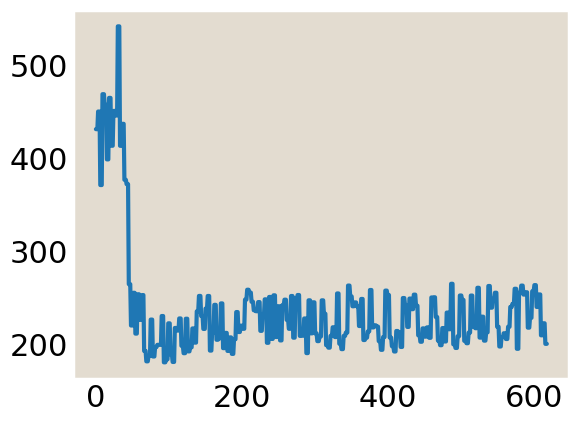

In [234]:
plt.plot(np.arange(618), np.average(arrs_norm[0][:, 300:350, 200:250], axis=(1,2)))

In [152]:
plt.imshow(makeImFromValsList(arrs_norm, mask_coords, (512, 512))[40])
plt.colorbar()

TypeError: list indices must be integers or slices, not tuple

In [146]:
np.where(arrs_norm[0]<0)

(array([  0,   0,   0, ..., 617, 617, 617], shape=(28983048,)),
 array([130, 130, 130, ..., 382, 382, 382], shape=(28983048,)),
 array([245, 246, 247, ..., 265, 266, 267], shape=(28983048,)))

In [155]:
type(mt_conc)

numpy.ndarray

In [774]:
# can i do emprical bound frac

In [776]:
def read_h5py(path_name, excludes=[], includes=[]):
    # Glob for directory parsing to get all .h5 files in the specified path
    h5files = glob.glob(path_name + '/*.h5')
    for excl in excludes:
        h5files=[file for file in h5files if excl not in file]
    for incl in includes:
        h5files=[file for file in h5files if incl in file]

    print(len(h5files))
        
    #print("HDF5 files found:", h5files)
    
    # Dictionary to store arrays from each file
    all_data = {}
    
    for file in h5files:
        file_data = []  # List to hold datasets for the current file
        
        with h5py.File(file, 'r') as h5file:
            def load_data(name, obj):
                if isinstance(obj, h5py.Dataset):
                    file_data.append(obj[:])  # Append dataset as a NumPy array
            
            # Visit all datasets in the file and load them into file_data
            h5file.visititems(load_data)
        
        #slice by 8 since the date has 8 didgits
        field_name = file.split('.h5')[0].split('tif')[-1][15:] #BRO, 15 is the number of digits in how we save datetime -> 20241114_201131 (formerly we had 8 since we didnt include time)
        #print(file + '\n')
        #print(field_name+ '\n')
            
        # Add this file's data to all_data with the filename as the key
        all_data[field_name] = file_data[0]
        
        
    return all_data

Poster child data import

In [777]:
gname_pc = '../../data/aster/Ncd_Aster_assay_12-11-2023/20sInterval_0.6uM_NCD_dimers_500uMATP_1.3uM_tubulin_2.8uM_A81D_1/20sInterval_0.6uM_NCD_dimers_500uMATP_1.3uM_tubulin_2.8uM_A81D_1_MMStack_Pos2.ome.tif'

h5spath_pc=gname_pc.split('data')[0]+'analyzed_data'+gname_pc.split('data')[1]+'/'
h5dic_pc = read_h5py(h5spath_pc)


18


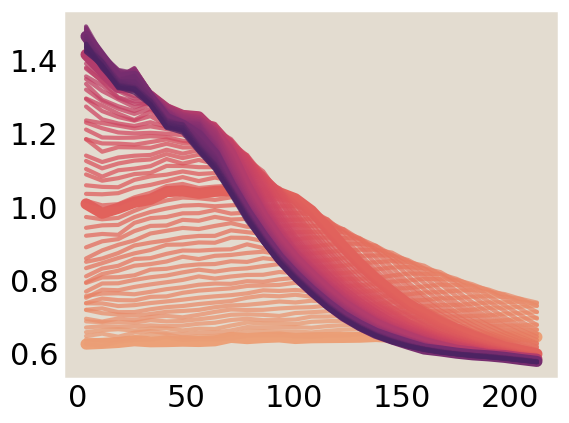

In [779]:
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min()]), vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max()]))(time))

for t, time in enumerate(h5dic_pc['timesMot'][12::2]):
    if np.isin(t*2+12, [12, 62, 112, 162]):
        plt.plot(h5dic_pc['all_rMotbins'][t*2+12],
                 h5dic_pc['all_rMotavgs'][t*2+12], 
                 alpha=1,
                 lw=8,
                 color=global_time(time))
    else:
        plt.plot(h5dic_pc['all_rMotbins'][t*2+12],
                 h5dic_pc['all_rMotavgs'][t*2+12], 
                 alpha=0.75,
                 color=global_time(time))

In [791]:
np.sum(timesMT[::4] == h5dic_pc['timesMot'][:155])

np.int64(155)

In [792]:
def boundfrac(mot, tub, Kd):
    return ( (mot+tub+Kd) - np.sqrt( (mot+tub+Kd)**2 - 4*mot*tub ) ) / (2*mot)

In [794]:
all_rMTavgs[::4]

array([[ 1.14929647,  1.12020208,  1.10462263, ...,  1.09790677,
         1.09859024,  1.09675274],
       [ 1.18205902,  1.14394198,  1.15952792, ...,  1.14121661,
         1.14225916,  1.13934019],
       [ 0.94949029,  0.93392687,  0.95151477, ...,  0.93222848,
         0.93406192,  0.93189577],
       ...,
       [17.61377869, 17.60760044, 17.27286203, ...,  0.83342693,
         0.87394148,  0.92232362],
       [16.28933307, 16.27277369, 15.94421939, ...,  0.73235738,
         0.76963248,  0.81719494],
       [15.3482886 , 15.34493211, 14.99624972, ...,  0.66683034,
         0.70150372,  0.74158326]], shape=(155, 29))

In [881]:
bf = boundfrac(2*h5dic_pc['all_rMotavgs'][:155], 13*all_rMTavgs[::4], 60)

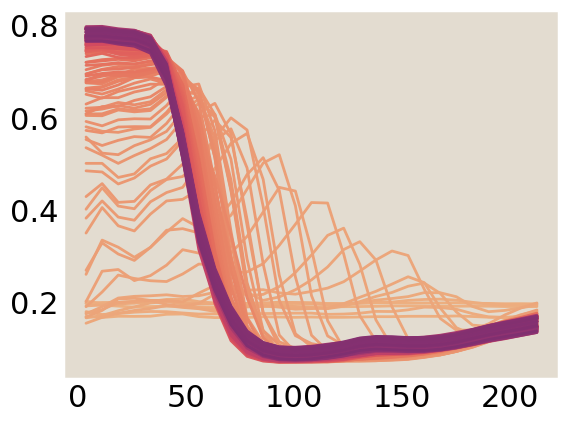

In [882]:
for t, time in enumerate(h5dic_pc['timesMot'][:155]):
    plt.plot(h5dic_pc['all_rMotbins'][0],
             bf[t], 
             alpha=1,
             lw=2,
             color=global_time(time))

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/3340761415.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


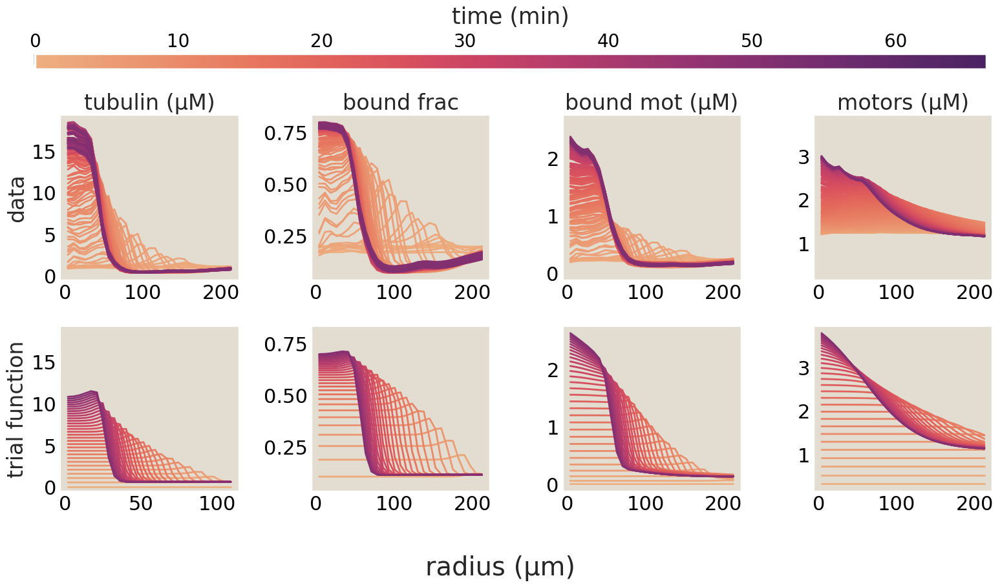

In [1349]:
#jenky solution to make this time colorbar the same as the comsol one for the S2 sweep at the bottom of this notebook
tmepdf = processDF('20260416_S2/atp_S2_22.txt')
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()]), vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()]))(time))


fig, ax = plt.subplots(2,4, figsize=(16, 8))
for t, time in enumerate(h5dic_pc['timesMot'][:155]):
    ax[0,0].plot(h5dic_pc['all_rMotbins'][0],
             all_rMTavgs[::4][t], 
             alpha=1,
             lw=2,
             color=global_time(time))
    ax[0,1].plot(h5dic_pc['all_rMotbins'][0],
             bf[t], 
             alpha=1,
             lw=2,
             color=global_time(time))
    ax[0,2].plot(h5dic_pc['all_rMotbins'][0],
             2*h5dic_pc['all_rMotavgs'][t]*bf[t], 
             alpha=1,
             lw=2,
             color=global_time(time))
    ax[0,3].plot(h5dic_pc['all_rMotbins'][0],
             2*h5dic_pc['all_rMotavgs'][t], 
             alpha=1,
             lw=2,
             color=global_time(time))

### Tubulin ###
#a = exponential(timesMT, 32, 475, 0.5)
a = exponential(timesMT, 100, 250, 15)
#b = exponential(timesMT, -18.23648431, 666.95695336,  17.32635126)
b = exponential(timesMT, -17, 660, 17)#-18, 660, 17)
c = exponential(timesMT, -120, 2000, 140)
d = 0.6
g = exponential(timesMT,  -18, 820, 18)#-20, 807, 18)
#g = exponential(timesMT, -24.64547175, 617.2580981,   17.32786614)
h = 80

### Motor ###
mlocparams = [194.51312176, 880.75748941,  22.53829382]
mheightparams = [-1.15971966e-07,  1.04668655e-03, -4.54772851e-01, 0]
mtauparams =[-7.51645693e-07,  7.53363485e-03,  2.22451989e+00, 0]
minfparams = [-2.41640883e-05,  6.17926972e-01]
fitpeakval = quadratic(h5dic_pc['timesMot'][:155], *mheightparams)
fitpeakloc = exponential(h5dic_pc['timesMot'][:155], *mlocparams)
fitdecayconst = quadratic(h5dic_pc['timesMot'][:155], *mtauparams)
fitinfval = linear(h5dic_pc['timesMot'][:155], *minfparams)

for t, time in enumerate(h5dic_pc['timesMot'][:155]):
    if t%5==0:
        tubf = crazyftn(all_rMTbins[t,:], a[t], b[t], c[t], d, g[t], h)
        motf = 2*sigmoid(all_rMTbins[t,:], fitpeakval[t], fitpeakloc[t], fitdecayconst[t], fitinfval[t])
        bf_trial = boundfrac(motf, 13*tubf, 60)
        ax[1,0].plot(all_rMTbins[t,:],
                 tubf, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1,1].plot(h5dic_pc['all_rMotbins'][0],
                 bf_trial, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1,2].plot(h5dic_pc['all_rMotbins'][0],
                 motf*bf_trial, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1,3].plot(h5dic_pc['all_rMotbins'][0],
                 motf, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
ax[0,0].set_title('tubulin (µM)')
ax[0,1].set_title('bound frac')
ax[0,2].set_title('bound mot (µM)')
ax[0,3].set_title('motors (µM)')

ax[0,0].set_ylabel('data')
ax[1,0].set_ylabel('trial function')

ax[1,0].set_ylim(ax[0,0].get_ylim())
ax[1,1].set_ylim(ax[0,1].get_ylim())
ax[0,2].set_ylim(ax[1,2].get_ylim())
ax[0,3].set_ylim(ax[1,3].get_ylim())

######
# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # [left, bottom, width, height]

# Create the colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()])/60, vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)


fig.supxlabel('radius (µm)')

fig.tight_layout()

plt.savefig('../../analyzed_data/aster/20260401_R2_norecycling_647MT_unlabelledNcDmotors/tubMotBound.pdf', bbox_inches='tight')#, transparent=True)

In [1356]:
h5dic_pc['timesMot'][:155]

array([   0.,   20.,   40.,   60.,   80.,  100.,  120.,  140.,  160.,
        180.,  200.,  220.,  240.,  260.,  280.,  300.,  320.,  340.,
        360.,  380.,  400.,  420.,  440.,  460.,  480.,  500.,  520.,
        540.,  560.,  580.,  600.,  620.,  640.,  660.,  680.,  700.,
        720.,  740.,  760.,  780.,  800.,  820.,  840.,  860.,  880.,
        900.,  920.,  940.,  960.,  980., 1000., 1020., 1040., 1060.,
       1080., 1100., 1120., 1140., 1160., 1180., 1200., 1220., 1240.,
       1260., 1280., 1300., 1320., 1340., 1360., 1380., 1400., 1420.,
       1440., 1460., 1480., 1500., 1520., 1540., 1560., 1580., 1600.,
       1620., 1640., 1660., 1680., 1700., 1720., 1740., 1760., 1780.,
       1800., 1820., 1840., 1860., 1880., 1900., 1920., 1940., 1960.,
       1980., 2000., 2020., 2040., 2060., 2080., 2100., 2120., 2140.,
       2160., 2180., 2200., 2220., 2240., 2260., 2280., 2300., 2320.,
       2340., 2360., 2380., 2400., 2420., 2440., 2460., 2480., 2500.,
       2520., 2540.,

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/1999230001.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


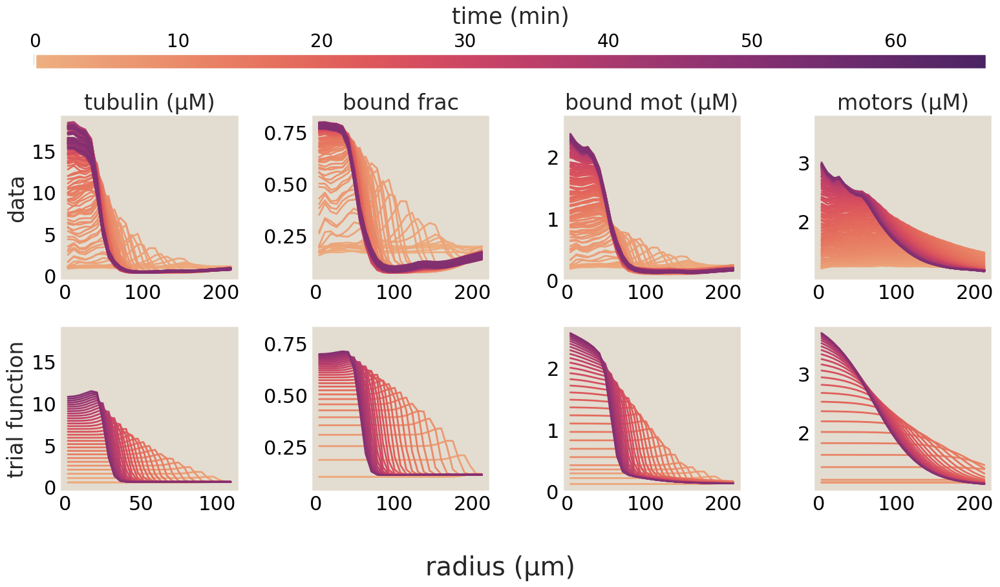

In [1358]:
#20260516 Comsol parameters match the motor fit in the 20250315_asterVis.ipnb --> so i am plotting those parameters here
#jenky solution to make this time colorbar the same as the comsol one for the S2 sweep at the bottom of this notebook
tmepdf = processDF('20260416_S2/atp_S2_22.txt')
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()]), vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()]))(time))


fig, ax = plt.subplots(2,4, figsize=(16, 8))
for t, time in enumerate(h5dic_pc['timesMot'][:155]):
    ax[0,0].plot(h5dic_pc['all_rMotbins'][0],
             all_rMTavgs[::4][t], 
             alpha=1,
             lw=2,
             color=global_time(time))
    ax[0,1].plot(h5dic_pc['all_rMotbins'][0],
             bf[t], 
             alpha=1,
             lw=2,
             color=global_time(time))
    ax[0,2].plot(h5dic_pc['all_rMotbins'][0],
             2*h5dic_pc['all_rMotavgs'][t]*bf[t], 
             alpha=1,
             lw=2,
             color=global_time(time))
    ax[0,3].plot(h5dic_pc['all_rMotbins'][0],
             2*h5dic_pc['all_rMotavgs'][t], 
             alpha=1,
             lw=2,
             color=global_time(time))

### Tubulin ###
#a = exponential(timesMT, 32, 475, 0.5)
a = exponential(timesMT, 100, 250, 15)
#b = exponential(timesMT, -18.23648431, 666.95695336,  17.32635126)
b = exponential(timesMT, -17, 660, 17)#-18, 660, 17)
c = exponential(timesMT, -120, 2000, 140)
d = 0.6
g = exponential(timesMT,  -18, 820, 18)#-20, 807, 18)
#g = exponential(timesMT, -24.64547175, 617.2580981,   17.32786614)
h = 80

### Motor ###
mlocparams = [252, 630,  33]
mheightparams = [-2.16e-07,  1.32e-03, -5.7e-01, 0]
mtauparams =[-5.96e-07,  4.3e-03,  8.3e+00, 0]
minfparams = [-5e-06,  5.68e-01]
fitpeakval = quadratic(h5dic_pc['timesMot'][:155], *mheightparams)
fitpeakloc = exponential(h5dic_pc['timesMot'][:155], *mlocparams)
fitdecayconst = quadratic(h5dic_pc['timesMot'][:155], *mtauparams)
fitinfval = linear(h5dic_pc['timesMot'][:155], *minfparams)

for t, time in enumerate(h5dic_pc['timesMot'][:155]):
    if t%5==0:
        tubf = crazyftn(all_rMTbins[t,:], a[t], b[t], c[t], d, g[t], h)
        motf = 2*sigmoid(all_rMTbins[t,:], fitpeakval[t], fitpeakloc[t], fitdecayconst[t], fitinfval[t])

        if t<5: #comsol piecewise for MT is 90 seconds
            tubf = crazyftn(all_rMTbins[5,:], a[5], b[5], c[5], d, g[5], h)
        if t<24:
            motf = 2*sigmoid(all_rMTbins[24,:], fitpeakval[24], fitpeakloc[24], fitdecayconst[24], fitinfval[24])
            
        bf_trial = boundfrac(motf, 13*tubf, 60)
        ax[1,0].plot(all_rMTbins[t,:],
                 tubf, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1,1].plot(h5dic_pc['all_rMotbins'][0],
                 bf_trial, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1,2].plot(h5dic_pc['all_rMotbins'][0],
                 motf*bf_trial, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1,3].plot(h5dic_pc['all_rMotbins'][0],
                 motf, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
ax[0,0].set_title('tubulin (µM)')
ax[0,1].set_title('bound frac')
ax[0,2].set_title('bound mot (µM)')
ax[0,3].set_title('motors (µM)')

ax[0,0].set_ylabel('data')
ax[1,0].set_ylabel('trial function')

ax[1,0].set_ylim(ax[0,0].get_ylim())
ax[1,1].set_ylim(ax[0,1].get_ylim())
ax[0,2].set_ylim(ax[1,2].get_ylim())
ax[0,3].set_ylim(ax[1,3].get_ylim())

######
# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # [left, bottom, width, height]

# Create the colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()])/60, vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)


fig.supxlabel('radius (µm)')

fig.tight_layout()

#plt.savefig('../../analyzed_data/aster/20260401_R2_norecycling_647MT_unlabelledNcDmotors/tubMotBound_20260516.pdf', bbox_inches='tight')#, transparent=True)

In [869]:
def processDF(filename):
    molperm3_to_uM = 1e3
    mtoum = 1e6
    comsol_file_path = "../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/"
    comment = '%'
    # constant gamma, motors as it has been
    tmepdf = pd.read_csv(comsol_file_path + filename, comment=comment, names=["position (µm)", "ATP (µM)"])
    tmepdf['ATP (µM)'] = tmepdf['ATP (µM)']*molperm3_to_uM
    tmepdf['position (µm)'] = tmepdf['position (µm)']*mtoum
    
    t_start = 0 #initial time
    t_end = 200*20 # final time
    spacing = 120 # seconds between each measurement
    interval = 1 #plotting interval
    
    numb_times = int((t_end-t_start)/spacing)+1
    
    comsol_times = np.linspace(t_start, t_start+spacing*(numb_times-1), numb_times) #given in s
    tot_points = len(tmepdf['position (µm)'])
    numb_points = int(tot_points/numb_times)
    
    comsol_time_ls = []
    for t in comsol_times:
        for i in range(numb_points):
            comsol_time_ls.append(t)
            
    tmepdf['time (s)']= comsol_time_ls

    return tmepdf

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/3949781338.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


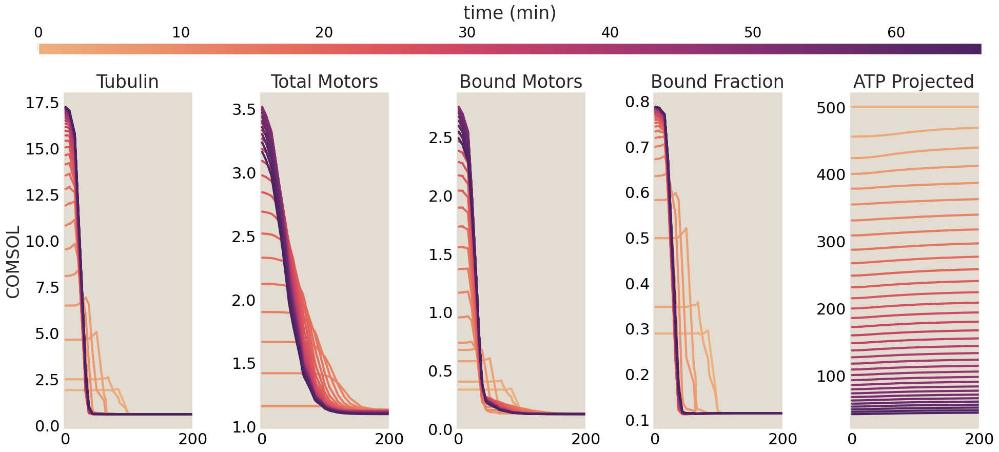

In [876]:


fig, ax = plt.subplots(1,5,figsize=(20,8), sharex=True,)

tmepdf = processDF('tubulinnotProjected.csv')
global_time_wcomsol=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([timesMT.min(), min(tmepdf['time (s)'])]), vmax=max([timesMT.max(), max(tmepdf['time (s)'])]))(time))

for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[0].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
ax[0].set_title('Tubulin', fontsize=25)
#---------------------------------------------------------------------#
tmepdf = processDF('motornotProjected.csv')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[1].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
ax[1].set_title('Total Motors', fontsize=25)
#---------------------------------------------------------------------#
tmepdf = processDF('boundmotors.csv')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[2].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
ax[2].set_title('Bound Motors', fontsize=25)
#---------------------------------------------------------------------#
tmepdf = processDF('boundfraction.csv')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[3].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)']/1000,
                   color=global_time_wcomsol(time))
ax[3].set_title('Bound Fraction', fontsize=25)
#---------------------------------------------------------------------#
tmepdf = processDF('atpProj.csv')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[4].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
ax[4].set_title('ATP Projected', fontsize=25)


# ax.set_xlabel('radius (µm)', fontsize=25)
# ax.set_ylabel('(µM)', fontsize=25)
#ax.set_title('ATP Projected', fontsize=25)

ax[0].set_xlim(-5, 200)
#ax.set_ylim(25, 430)
# ax.axvline(60, c='k', lw=0.5)
# ax.axvline(100, c='k', lw=0.5)
# plt.savefig('../../analyzed_data/COMSOL/20260310-ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid_stepFtngamma/motordata.pdf', 
#             bbox_inches='tight')


######
# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # [left, bottom, width, height]

# Create the colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(tmepdf['time (s)'])/60, 
                                                                 vmax=max(tmepdf['time (s)'])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)

ax[0].set_ylabel('COMSOL')
fig.tight_layout()

In [ ]:
13*(1/(1+exp(-100*(r-tubpeak(pwMTt(t)))))) * ((tubheight(pwMTt(t))-tubxinf)*exp(-(r-tubpeak(pwMTt(t)))^2/tubrightsig(pwMTt(t))) + tubxinf)+ 13*(1/(1+exp(100*(r-tubpeak(pwMTt(t)))))) * ((tubheight(pwMTt(t))-tubx0(pwMTt(t)))*exp(-(r-tubpeak(pwMTt(t)))^2/tubls) + tubx0(pwMTt(t)))

In [861]:
np.shape(motf*)

(29,)

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)


Text(0.5, 1.0, 'motors')

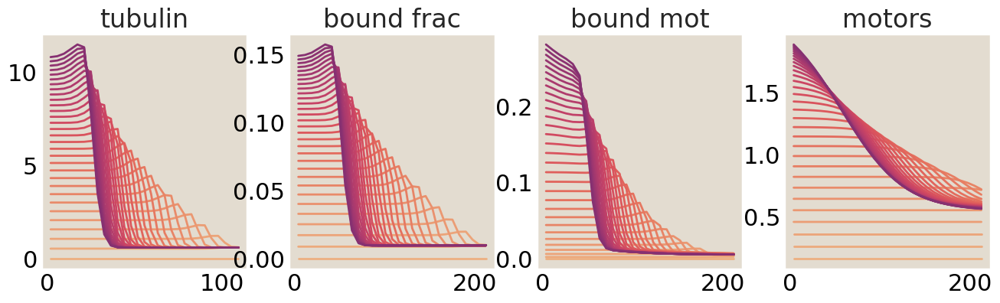

In [863]:
#trial ftn 
fig, ax = plt.subplots(1,4, figsize=(16, 4))

### Tubulin ###
#a = exponential(timesMT, 32, 475, 0.5)
a = exponential(timesMT, 100, 250, 15)
#b = exponential(timesMT, -18.23648431, 666.95695336,  17.32635126)
b = exponential(timesMT, -17, 660, 17)#-18, 660, 17)
c = exponential(timesMT, -120, 2000, 140)
d = 0.6
g = exponential(timesMT,  -18, 820, 18)#-20, 807, 18)
#g = exponential(timesMT, -24.64547175, 617.2580981,   17.32786614)
h = 80

### Motor ###
mlocparams = [194.51312176, 880.75748941,  22.53829382]
mheightparams = [-1.15971966e-07,  1.04668655e-03, -4.54772851e-01, 0]
mtauparams =[-7.51645693e-07,  7.53363485e-03,  2.22451989e+00, 0]
minfparams = [-2.41640883e-05,  6.17926972e-01]
fitpeakval = quadratic(h5dic_pc['timesMot'][:155], *mheightparams)
fitpeakloc = exponential(h5dic_pc['timesMot'][:155], *mlocparams)
fitdecayconst = quadratic(h5dic_pc['timesMot'][:155], *mtauparams)
fitinfval = linear(h5dic_pc['timesMot'][:155], *minfparams)

for t, time in enumerate(h5dic_pc['timesMot'][:155]):
    if t%5==0:
        tubf = crazyftn(all_rMTbins[t,:], a[t], b[t], c[t], d, g[t], h)
        motf = sigmoid(all_rMTbins[t,:], fitpeakval[t], fitpeakloc[t], fitdecayconst[t], fitinfval[t])
        bf_trial = boundfrac(motf, tubf, 60)
        ax[0].plot(all_rMTbins[t,:],
                 tubf, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[1].plot(h5dic_pc['all_rMotbins'][0],
                 bf_trial, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[2].plot(h5dic_pc['all_rMotbins'][0],
                 motf*bf_trial, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
        ax[3].plot(h5dic_pc['all_rMotbins'][0],
                 motf, 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
ax[0].set_title('tubulin')
ax[1].set_title('bound frac')
ax[2].set_title('bound mot')
ax[3].set_title('motors')


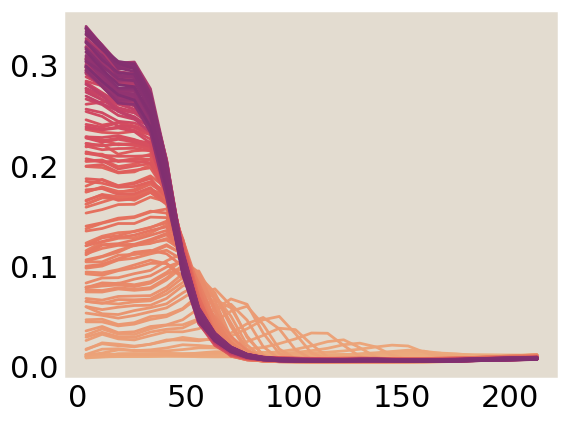

In [806]:
for t, time in enumerate(h5dic_pc['timesMot'][:155]):
    plt.plot(h5dic_pc['all_rMotbins'][0],
             h5dic_pc['all_rMotavgs'][t]*bf[t], 
             alpha=1,
             lw=2,
             color=global_time(time))

In [820]:
bm = h5dic_pc['all_rMotavgs'][:155]*bf

In [821]:
sigParams=[]
for t in tqdm(np.arange(155)):
    try:
        sigParams.append(fitSigmoid(h5dic_pc['all_rMotbins'][0], 
                                    bm[t], 
                                    [bm[t].max()-bm[t].min(), 150-0.5*t, 1, bm[t].min()]))
    except RuntimeError as e:
        print(f"Skipping {t} due to error: {e}")

sigParams=np.array(sigParams)

  0%|          | 0/155 [00:00<?, ?it/s]

Skipping 0 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.
Skipping 1 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.


/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/865711499.py:2: RuntimeWarning: overflow encountered in exp
  return a/(1+np.exp((arr - b)/c)) + d
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/865711499.py:4: OptimizeWarning: Covariance of the parameters could not be estimated
  param,_ = curve_fit(sigmoid, x, y, p0)


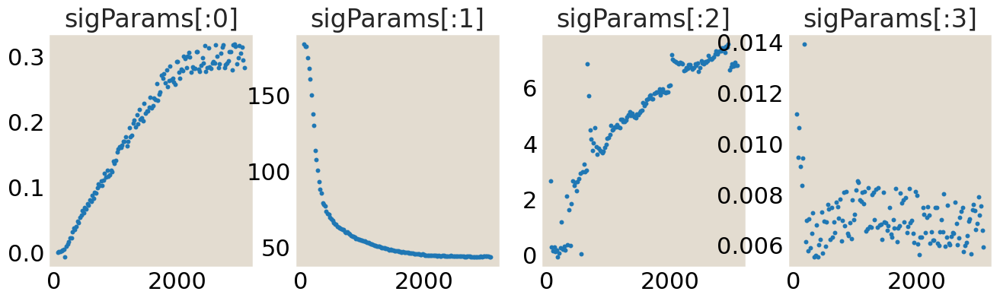

In [822]:
fig, ax = plt.subplots(1,4, figsize=(16,4))
for i in range(4):
    ax[i].scatter(timesMT[::4][3:], sigParams[1:,i], s=5)
    ax[i].set_title(f'sigParams[:{i}]')

[197.00317935 239.79970845  46.15936376]


Text(0.5, 0, 'time (s)')

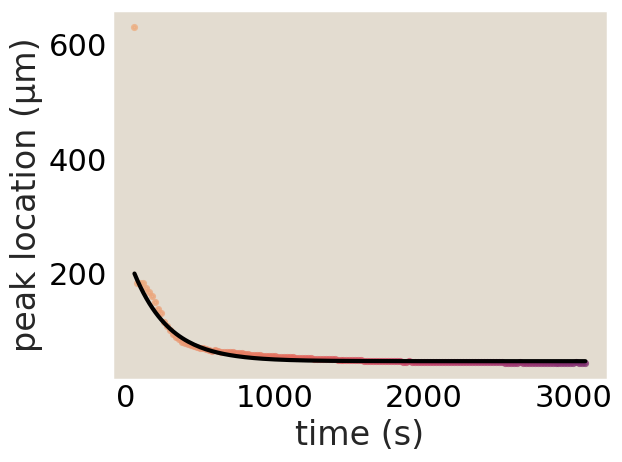

In [824]:
tublocparams = fitExponential(timesMT[::4][3:], sigParams[1:,1], [252, 30*20, 30])
print(tublocparams)
#plt.scatter(timesMot[24:], sigParams[:,1], s=5)
plt.plot(timesMT[::4][3:], exponential(timesMT[::4][3:], *tublocparams), c='k')
for t, time in enumerate(timesMT[::4]):
    if t>=3:
        plt.scatter(timesMT[::4][t],
                 sigParams[t-3,1], 
                 alpha=0.75,
                 color=global_time(time), s=10)
plt.ylabel(r'peak location (µm)')
plt.xlabel(r'time (s)')

[-3.91793644e-08  1.99391114e-04  5.14946450e-02  4.20947726e+02]


Text(0.5, 0, 'time (s)')

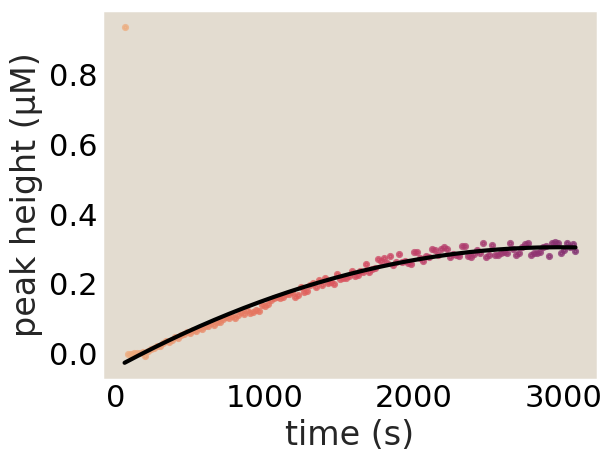

In [826]:
tubheightparams = fitQuadratic(timesMT[::4][3:], sigParams[1:,0], [-8e-5*400, 0.02*20, 150, 0])
print(tubheightparams)
#plt.scatter(timesMot[24:], sigParams[:,0], s=5)
plt.plot(timesMT[::4][3:], quadratic(timesMT[::4][3:], *tubheightparams), c='k')
for t, time in enumerate(timesMT[::4]):
    if t>=3:
        plt.scatter(timesMT[::4][t],
                 sigParams[t-3,0], 
                 alpha=0.75,
                 color=global_time(time), s=10)
plt.ylabel(r'peak height (µM)')
plt.xlabel(r'time (s)')
#plt.savefig(h5spath_pc+'20250610_mheightparams.pdf', bbox_inches='tight', transparent=True)

[-8.69967468e-07  3.88381809e-03  2.71756302e+00  6.01660479e+02]


Text(0.5, 0, 'time (s)')

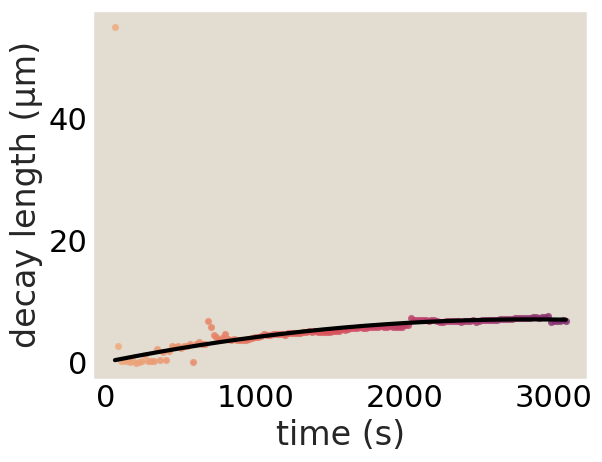

In [828]:
tubtauparams = fitQuadratic(timesMT[::4][3:], sigParams[1:,2], [-2e-4*400, 0.09*20, 150, 0])
print(tubtauparams)
#plt.scatter(timesMot[24:], sigParams[:,2], s=5)
plt.plot(timesMT[::4][3:], quadratic(timesMT[::4][3:], *tubtauparams), c='k')
for t, time in enumerate(timesMT[::4]):
    if t>=3:
        plt.scatter(timesMT[::4][t],
                 sigParams[t-3,2], 
                 alpha=0.75,
                 color=global_time(time), s=10)
plt.ylabel(r'decay length (µm)')
plt.xlabel(r'time (s)')
#plt.savefig(h5spath_pc+'20250610_mtauparams.pdf', bbox_inches='tight', transparent=True)

[-3.25925744e-07  7.59248078e-03]


Text(0.5, 0, 'time (s)')

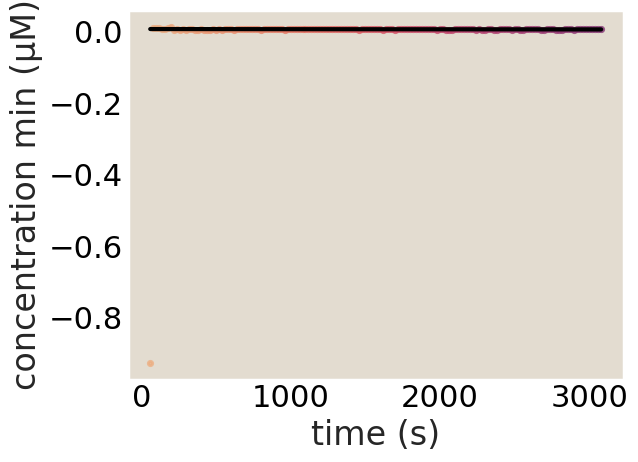

In [829]:
tubinfparams = fitLinear(timesMT[::4][3:], sigParams[1:,3], [-0.3/10, 0.58])
print(tubinfparams)
#plt.scatter(timesMot[24:], sigParams[:,3], s=5)
plt.plot(timesMT[::4][3:], linear(timesMT[::4][3:], *tubinfparams), c='k')
for t, time in enumerate(timesMT[::4]):
    if t>=3:
        plt.scatter(timesMT[::4][t],
                 sigParams[t-3,3], 
                 alpha=0.75,
                 color=global_time(time), s=10)
plt.ylabel(r'concentration min (µM)')
plt.xlabel(r'time (s)')
#sns.despine(trim=True)
#plt.savefig(h5spath_pc+'20250610_minfparams.pdf', bbox_inches='tight', transparent=True)

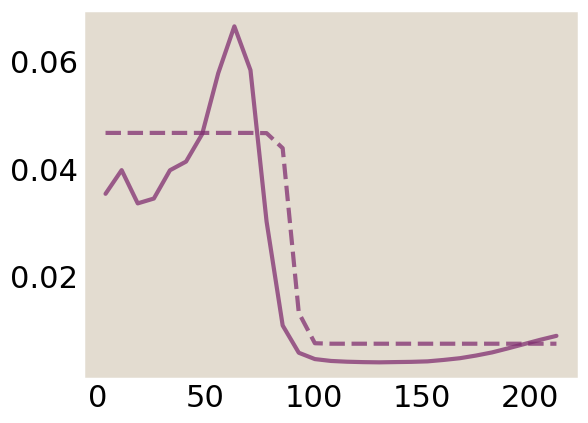

In [848]:
t=18

plt.plot(h5dic_pc['all_rMotbins'][t],
                 bm[t], 
                 alpha=0.75,
                 color=global_time(time))
plt.plot(h5dic_pc['all_rMotbins'][t],
                     sigmoid(h5dic_pc['all_rMotbins'][t], fitpeakval[t-3], fitpeakloc[t-3], fitdecayconst[t-3], fitinfval[t-3]), 
                     alpha=0.75,
                     ls='--',
                     color=global_time(time))#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)        
    

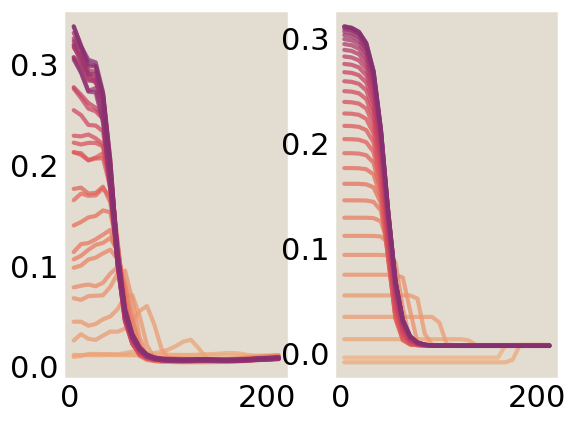

In [843]:
fitpeakval = quadratic(timesMT[::4][3:], *tubheightparams)
fitpeakloc = exponential(timesMT[::4][3:], *tublocparams)
fitdecayconst = quadratic(timesMT[::4][3:], *tubtauparams)
fitinfval = linear(timesMT[::4][3:], *tubinfparams)

fig, ax = plt.subplots(1,2)
for t, time in enumerate(timesMT[::4]):
    if t%5==0:
        ax[0].plot(h5dic_pc['all_rMotbins'][t],
                 bm[t], 
                 alpha=0.75,
                 color=global_time(time))#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)        
     
        if t>=3:
            ax[1].plot(h5dic_pc['all_rMotbins'][t],
                     sigmoid(h5dic_pc['all_rMotbins'][t], fitpeakval[t-3], fitpeakloc[t-3], fitdecayconst[t-3], fitinfval[t-3]), 
                     alpha=0.75,
                     color=global_time(time))#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)        
        else:
            ax[1].plot(h5dic_pc['all_rMotbins'][t],
                     sigmoid(h5dic_pc['all_rMotbins'][3], fitpeakval[3], fitpeakloc[3], fitdecayconst[3], fitinfval[3]), 
                     alpha=0.75,
                     color=global_time(time))#sns.color_palette("flare", as_cmap=True)(time/rMotmids.shape[0]), lw=2)        


# ax[0].set_ylim(0.5, 1.95)
# ax[1].set_ylim(0.5, 1.95)

## try with crazy ftn

In [850]:
fits_bm = []
fittedindex_bm = []
cov_bm = []
ssr_bm = []
for i in tqdm(np.arange(len(bm))):
    try:
        # your code that might fail
        fit_bm, cov_ = fitcrazyftn(all_rMTbins[i,:], bm[i,:], [exponential(timesMT[::4][i], *MTmaxlocfit), exponential(timesMT[::4][i], *MTmaxfit), 5, 1.1, sigmoid(timesMT[::4][i], *MTx0fit), 5]) #[25, 10, 5, 1.1, 7, 5]
        fits_bm.append(fit_bm)
        fittedindex_bm.append(i)
        cov_bm.append(cov_)
        ssr.append(np.sum((bm[i] - crazyftn(all_rMTbins[i,:], *fit_bm))**2))
    except RuntimeError as e:
        print(f"Skipping {i} due to error: {e}")
        continue

  0%|          | 0/155 [00:00<?, ?it/s]

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: invalid value encountered in multiply
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: invalid value encountered in multiply
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:7: OptimizeWarning: Covariance of the parameters could not be estimated
  param,_ = curve_fit(crazyftn, x, y, p0)


Skipping 18 due to error: Optimal parameters not found: Number of calls to function has reached maxfev = 1400.


/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in multiply
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)


/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:2: RuntimeWarning: overflow encountered in exp
  right = (1/(1+np.exp(-100*(arr-a)))) * ((b-d)*np.exp(-(arr-a)**2/c) + d)
/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2175448366.py:3: RuntimeWarning: overflow encountered in exp
  left = (1/(1+np.exp(100*(arr-a)))) * ((b-g)*np.exp(-(arr-a)**2/h) + g)


IndexError: index 160 is out of bounds for axis 0 with size 155

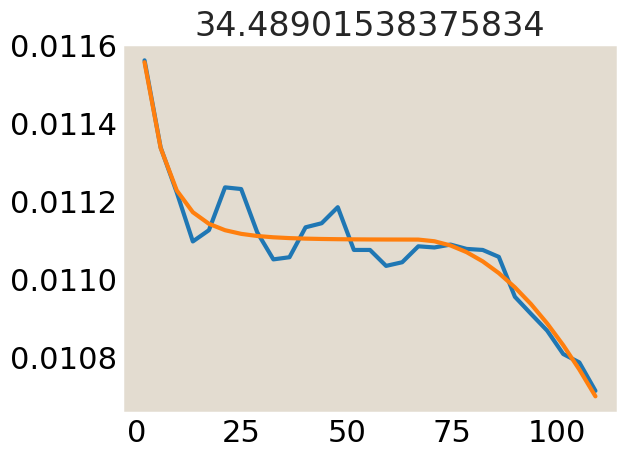

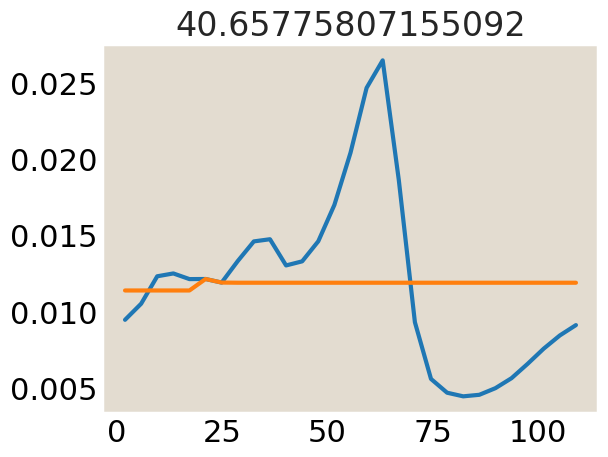

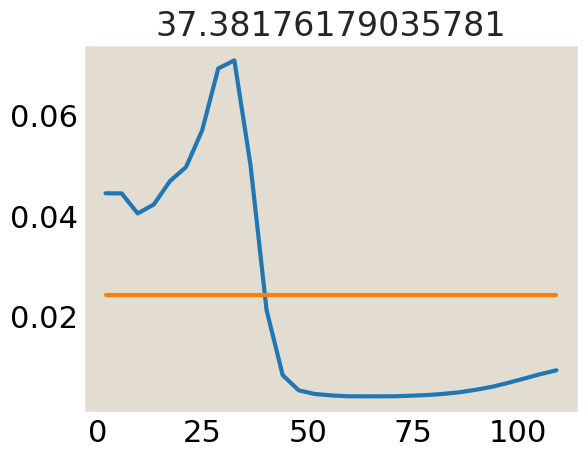

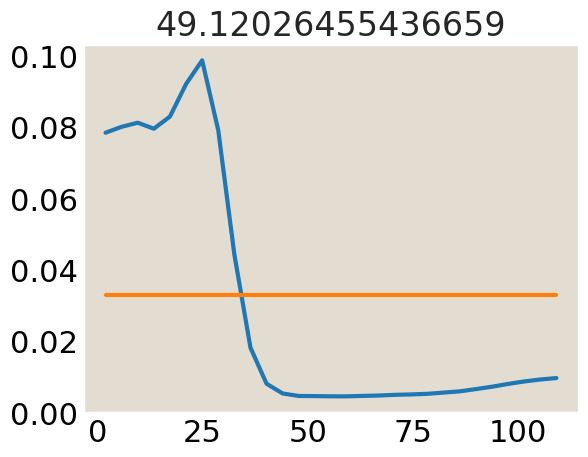

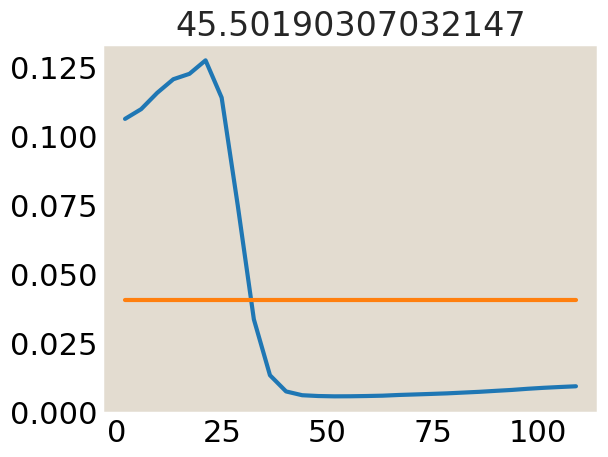

...

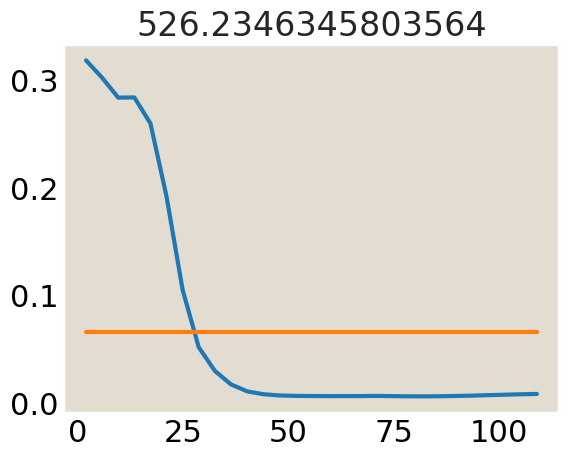

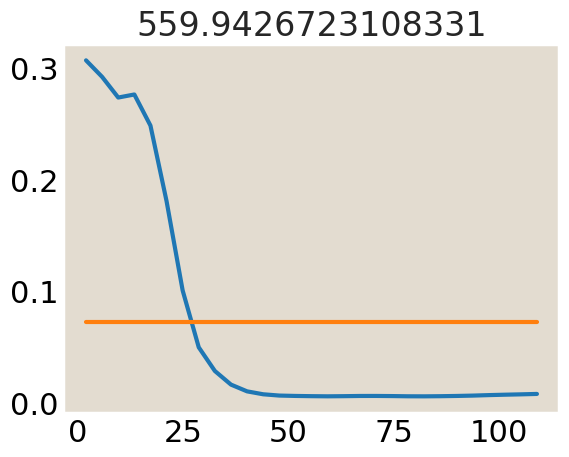

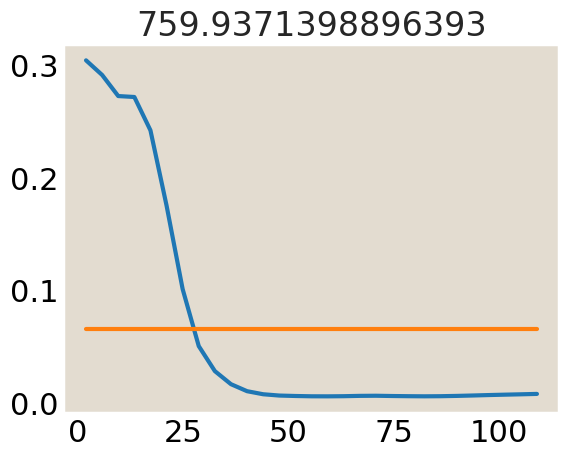

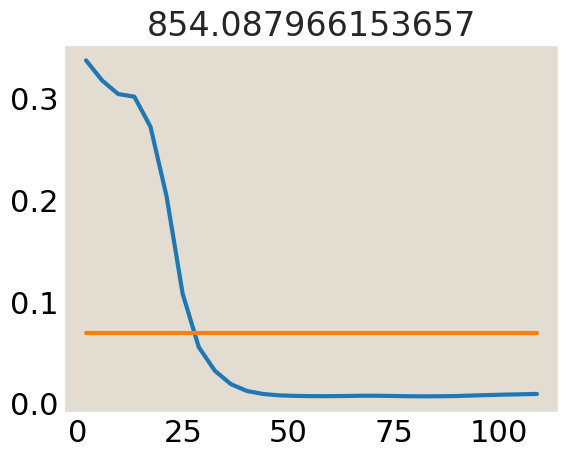

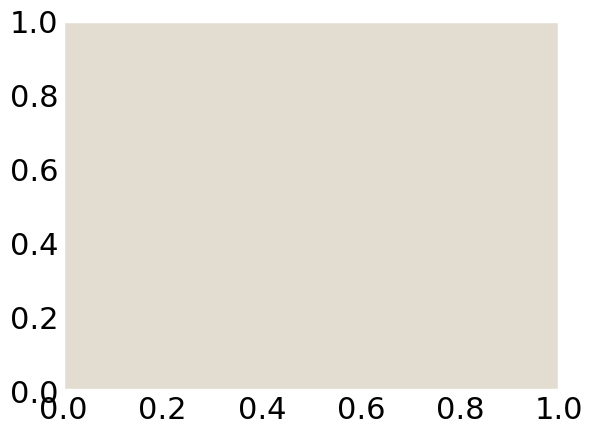

In [851]:
for i in np.arange(0, 155, 10):#len(all_rMTavgs)):
    fig, ax = plt.subplots()
    ax.plot(all_rMTbins[i], bm[i])
    fitcurveplot = crazyftn(all_rMTbins[i,:], *fits_bm[i])
    ax.plot(all_rMTbins[i,:], fitcurveplot)
    #plt.scatter(all_rMTbins[i][MTmaxloc[i]], MTmax[i], c='k', s=10)
    ax.set_title(np.sum((all_rMTavgs[i] - fitcurveplot)**2))
    #ax.set_ylim(0, 20)

# Param Sweep

In [1091]:
sweepfile = '../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414_parametricCutLineAandBF.csv'
with open(sweepfile, 'r') as f:
    for line in f:
        if line.startswith('%'):
            header = line
        else:
            break #stop when there are no more #

header = header[1:].split(',')#.strip().split()

sweepdf_ = pd.read_csv(sweepfile, delimiter=',', comment='%', names=header)

In [1092]:
sweepdf = pd.DataFrame()
sweepdf_X = sweepdf_[' X']
ones = np.ones(len(sweepdf_X))

for key in tqdm(sweepdf_.keys()[3:]):
    tempdf = pd.DataFrame()
    simfeild = key.split(' @')[0]
    simtime = float(key.split('@ t=')[1].split(';')[0])
    simKdmotmt = float(key.split('Kd_motmt=')[1].split(';')[0])
    simKdatp = float(key.split('Katp=')[1].split(';')[0])
    simgamma = float(key.split('gamma_motmax=')[1].split(';')[0])
    simtub = float(key.split('tubbindsite=')[1].split(';')[0])
    simD = float(key.split('D=')[1].split(';')[0])
    
    tempdf['t'] = simtime*ones
    tempdf['X'] = sweepdf_X
    tempdf['feild'] = simfeild
    tempdf['feildval'] = sweepdf_[key]
    tempdf['Kd_motmt'] = simKdmotmt*ones
    tempdf['Katp'] = simKdatp*ones
    tempdf['gamma_motmax'] = simgamma*ones
    tempdf['tubbindsite'] = simtub*ones
    tempdf['D'] = simD*ones

    sweepdf= pd.concat([sweepdf, tempdf])
    #simfeild, simtime, simKdmotmt, simKdatp, simgamma, simtub

  0%|          | 0/4896 [00:00<?, ?it/s]

In [1093]:
combos = sweepdf[["Kd_motmt", "Katp", "gamma_motmax", "tubbindsite", "D"]].drop_duplicates()

In [1094]:
combos

,Kd_motmt,Katp,gamma_motmax,tubbindsite,D
0,0.03,0.0115,2.0,13.0,8.000000e-11
0,0.03,0.0115,2.0,13.0,1.200000e-10
0,0.03,0.0115,2.0,26.0,8.000000e-11
0,0.03,0.0115,2.0,26.0,1.200000e-10
0,0.03,0.0115,4.0,13.0,8.000000e-11
...,...,...,...,...,...
0,0.12,0.0460,2.0,26.0,1.200000e-10
0,0.12,0.0460,4.0,13.0,8.000000e-11
0,0.12,0.0460,4.0,13.0,1.200000e-10
0,0.12,0.0460,4.0,26.0,8.000000e-11


In [1061]:
simfeild = sweepdf.keys()[4].split(' @')[0]
simtime = float(sweepdf.keys()[4].split('@ t=')[1].split(';')[0])
simKdmotmt = float(sweepdf.keys()[4].split('Kd_motmt=')[1].split(';')[0])
simKdatp = float(sweepdf.keys()[4].split('Katp=')[1].split(';')[0])
simgamma = float(sweepdf.keys()[4].split('gamma_motmax=')[1].split(';')[0])
simtub = float(sweepdf.keys()[4].split('tubbindsite=')[1].split(';')[0])
simfeild, simtime, simKdmotmt, simKdatp, simgamma, simtub



IndexError: list index out of range

In [920]:
sweepdf

,X,Y,Z,A (mol/m^3) @ t=0; Kd_motmt=1; Katp=0.023; gamma_motmax=10; tubbindsite=39,msig(r;t) (mol/m^3) @ t=0; Kd_motmt=1; Katp=0.023; gamma_motmax=10; tubbindsite=39,an8(r;t) @ t=0; Kd_motmt=1; Katp=0.023; gamma_motmax=10; tubbindsite=39,tubsig(r;t)/tubbindsite (mol/m^3) @ t=0; Kd_motmt=1; Katp=0.023; gamma_motmax=10; tubbindsite=39,A (mol/m^3) @ t=120; Kd_motmt=1; Katp=0.023; gamma_motmax=10; tubbindsite=39,msig(r;t) (mol/m^3) @ t=120; Kd_motmt=1; Katp=0.023; gamma_motmax=10; tubbindsite=39,an8(r;t) @ t=120; Kd_motmt=1; Katp=0.023; gamma_motmax=10; tubbindsite=39,...,an8(r;t) @ t=3720; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1,tubsig(r;t)/tubbindsite (mol/m^3) @ t=3720; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1,A (mol/m^3) @ t=3840; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1,msig(r;t) (mol/m^3) @ t=3840; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1,an8(r;t) @ t=3840; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1,tubsig(r;t)/tubbindsite (mol/m^3) @ t=3840; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1,A (mol/m^3) @ t=3960; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1,msig(r;t) (mol/m^3) @ t=3960; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1,an8(r;t) @ t=3960; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1,tubsig(r;t)/tubbindsite (mol/m^3) @ t=3960; Kd_motmt=0.06; Katp=0.023; gamma_motmax=10; tubbindsite=1\n
0,-0.000166,-5.000000e-05,-0.000250,0.499998,0.001131,0.02284,0.0006,0.470180,0.001131,0.02284,...,0.009726,0.0006,0.201018,0.001098,0.009727,0.0006,0.195005,0.001096,0.009727,0.0006
1,-0.000161,-5.000000e-05,-0.000306,0.499998,0.001131,0.02284,0.0006,0.470587,0.001131,0.02284,...,0.009726,0.0006,0.201483,0.001098,0.009727,0.0006,0.195455,0.001096,0.009727,0.0006
2,-0.000229,-5.000000e-05,-0.000288,0.499998,0.001131,0.02284,0.0006,0.470714,0.001131,0.02284,...,0.009726,0.0006,0.201687,0.001098,0.009727,0.0006,0.195653,0.001096,0.009727,0.0006
3,-0.000187,7.873318e-08,-0.000234,0.499998,0.001131,0.02284,0.0006,0.470181,0.001131,0.02284,...,0.009726,0.0006,0.201018,0.001098,0.009727,0.0006,0.195005,0.001096,0.009727,0.0006
4,-0.000212,-5.000000e-05,-0.000212,0.499998,0.001131,0.02284,0.0006,0.470180,0.001131,0.02284,...,0.009726,0.0006,0.201019,0.001098,0.009727,0.0006,0.195005,0.001096,0.009727,0.0006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1190,0.000150,5.000000e-05,0.000128,0.499998,0.001131,0.02284,0.0006,0.467807,0.001131,0.02284,...,0.009726,0.0006,0.199621,0.001098,0.009727,0.0006,0.193653,0.001096,0.009727,0.0006
1191,0.000107,-2.004148e-20,0.000190,0.499998,0.001131,0.02284,0.0006,0.468535,0.001131,0.02284,...,0.009726,0.0006,0.199953,0.001098,0.009727,0.0006,0.193973,0.001096,0.009727,0.0006
1192,0.000162,2.500000e-05,0.000153,0.499998,0.001131,0.02284,0.0006,0.468677,0.001131,0.02284,...,0.009726,0.0006,0.200022,0.001098,0.009727,0.0006,0.194041,0.001096,0.009727,0.0006
1193,0.000090,5.000000e-05,0.000172,0.499998,0.001131,0.02284,0.0006,0.467668,0.001131,0.02284,...,0.009726,0.0006,0.199563,0.001098,0.009727,0.0006,0.193597,0.001096,0.009727,0.0006


In [972]:
np.unique(sweepdf['t'])

array([   0.,  120.,  240.,  360.,  480.,  600.,  720.,  840.,  960.,
       1080., 1200., 1320., 1440., 1560., 1680., 1800., 1920., 2040.,
       2160., 2280., 2400., 2520., 2640., 2760., 2880., 3000., 3120.,
       3240., 3360., 3480., 3600., 3720., 3840., 3960.])

(-10.0, 200.0)

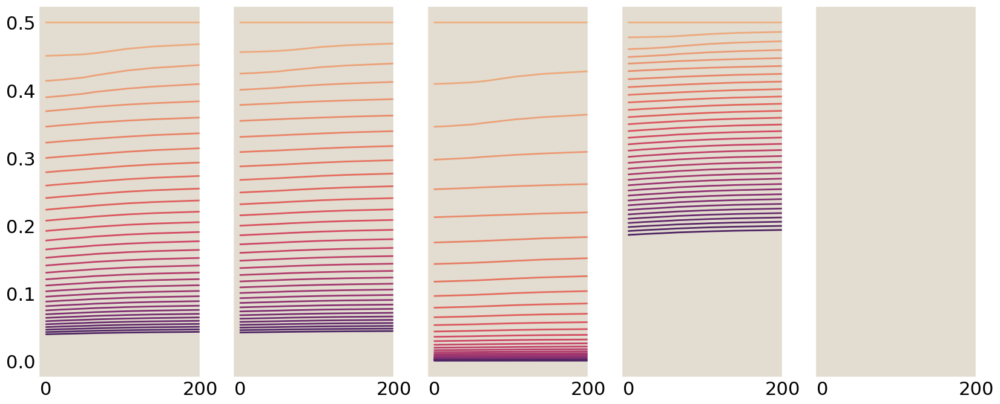

In [1014]:
# comboi = 0
# print(combos.iloc[comboi])
fig, ax = plt.subplots(1, 5, figsize=(20,8), sharex=True, sharey=True)
for comboi in range(len(combos)):
    for t, time in enumerate(np.unique(sweepdf['t'])):
        subsetdf = sweepdf[
        (sweepdf["t"] == time) &
        (sweepdf["Kd_motmt"] == combos.iloc[comboi]["Kd_motmt"]) &
        (sweepdf["Katp"] == combos.iloc[comboi]["Katp"]) &
        (sweepdf["gamma_motmax"] == combos.iloc[comboi]["gamma_motmax"]) &
        (sweepdf["tubbindsite"] == combos.iloc[comboi]["tubbindsite"]) &
        (sweepdf["feild"] == "A (mol/m^3)")
        ]
        subsetdf = subsetdf.sort_values(by=["X"])
        ax[comboi].plot(subsetdf['X']*1e6,
                 subsetdf['feildval'], 
                 alpha=1,
                 lw=2,
                 color=global_time(time))
ax[4].set_xlim(-10, 200)

In [1040]:
combos.iloc[30]

Kd_motmt        6.000000e-02
Katp            1.150000e-02
gamma_motmax    4.000000e+00
tubbindsite     2.600000e+01
D               8.000000e-11
Name: 0, dtype: float64

(-10.0, 200.0)

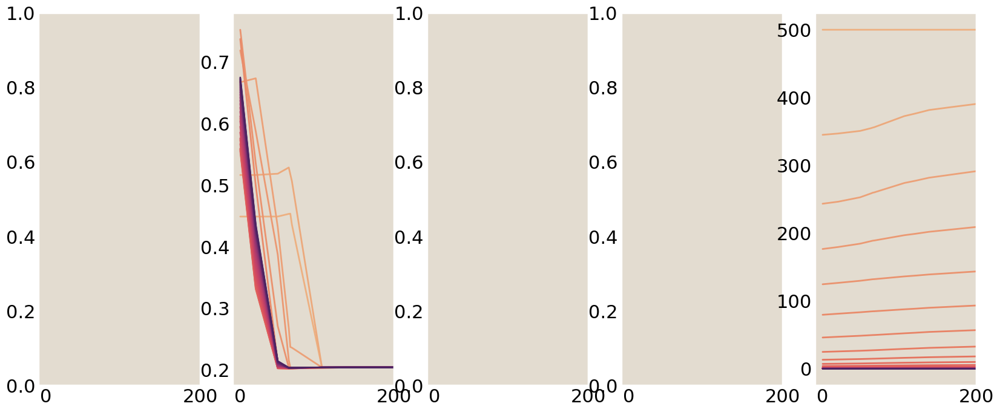

In [1098]:
comboi = 30
# print(combos.iloc[comboi])
fig, ax = plt.subplots(1, 5, figsize=(20,8), sharex=True)
 
for t, time in enumerate(np.unique(sweepdf['t'])):
    # #tubulin
    # subsetdftub = sweepdf[
    # (sweepdf["t"] == time) &
    # (sweepdf["Kd_motmt"] == combos.iloc[comboi]["Kd_motmt"]) &
    # (sweepdf["Katp"] == combos.iloc[comboi]["Katp"]) &
    # (sweepdf["gamma_motmax"] == combos.iloc[comboi]["gamma_motmax"]) &
    # (sweepdf["tubbindsite"] == combos.iloc[comboi]["tubbindsite"]) &
    # (sweepdf["D"] == combos.iloc[comboi]["D"]) &
    # (sweepdf["feild"] == "tubsig(r;t)/tubbindsite (mol/m^3)")
    # ]
    # subsetdftub = subsetdftub.sort_values(by=["X"])
    # ax[0].plot(subsetdftub['X']*1e6,
    #          subsetdftub['feildval']*1e3, 
    #          alpha=1,
    #          lw=2,
    #          color=global_time(time))

    #bound fraction
    subsetdfbf = sweepdf[
    (sweepdf["t"] == time) &
    (sweepdf["Kd_motmt"] == combos.iloc[comboi]["Kd_motmt"]) &
    (sweepdf["Katp"] == combos.iloc[comboi]["Katp"]) &
    (sweepdf["gamma_motmax"] == combos.iloc[comboi]["gamma_motmax"]) &
    (sweepdf["tubbindsite"] == combos.iloc[comboi]["tubbindsite"]) &
    (sweepdf["D"] == combos.iloc[comboi]["D"]) &
    (sweepdf["feild"] == "an8(r;t)")
    ]
    subsetdfbf = subsetdfbf.sort_values(by=["X"])
    ax[1].plot(subsetdfbf['X']*1e6,
             subsetdfbf['feildval'], 
             alpha=1,
             lw=2,
             color=global_time(time))

   #  #mot
   #  subsetdfmot = sweepdf[
   #  (sweepdf["t"] == time) &
   #  (sweepdf["Kd_motmt"] == combos.iloc[comboi]["Kd_motmt"]) &
   #  (sweepdf["Katp"] == combos.iloc[comboi]["Katp"]) &
   #  (sweepdf["gamma_motmax"] == combos.iloc[comboi]["gamma_motmax"]) &
   #  (sweepdf["tubbindsite"] == combos.iloc[comboi]["tubbindsite"]) &
   #  (sweepdf["D"] == combos.iloc[comboi]["D"]) &
   #  (sweepdf["feild"] == "msig(r;t) (mol/m^3)")
   #  ]
   #  subsetdfmot = subsetdfmot.sort_values(by=["X"])
   #  ax[3].plot(subsetdfmot['X']*1e6,
   #           subsetdfmot['feildval']*1e3, 
   #           alpha=1,
   #           lw=2,
   #           color=global_time(time))

   # #bound mot
   #  ax[2].plot(subsetdfmot['X']*1e6,
   #           subsetdfmot['feildval']*subsetdfbf['feildval']*1e3, 
   #           alpha=1,
   #           lw=2,
   #           color=global_time(time))
    
    #atp
    subsetdfatp = sweepdf[
    (sweepdf["t"] == time) &
    (sweepdf["Kd_motmt"] == combos.iloc[comboi]["Kd_motmt"]) &
    (sweepdf["Katp"] == combos.iloc[comboi]["Katp"]) &
    (sweepdf["gamma_motmax"] == combos.iloc[comboi]["gamma_motmax"]) &
    (sweepdf["tubbindsite"] == combos.iloc[comboi]["tubbindsite"]) &
    (sweepdf["D"] == combos.iloc[comboi]["D"]) &
    (sweepdf["feild"] == "A (mol/m^3)")
    ]
    subsetdfatp = subsetdfatp.sort_values(by=["X"])
    ax[4].plot(subsetdfatp['X']*1e6,
             subsetdfatp['feildval']*1e3, 
             alpha=1,
             lw=2,
             color=global_time(time))

ax[4].set_xlim(-10, 200)

In [1113]:
file='../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414_parametricCutLinean8.csv'
with open(file, 'r') as f:
    for line in f:
        if line.startswith('%'):
            header = line
        else:
            break #stop when there are no more #

header = header[1:].split(',')#.strip().split()

dftest_ = pd.read_csv(file, delimiter=',', comment='%', names=header)

In [1121]:
dftest = pd.DataFrame()
dftest_X = dftest_[' X']
ones = np.ones(len(dftest_X))

for key in tqdm(dftest_.keys()[3:]):
    tempdf = pd.DataFrame()
    simfeild = key.split(' @')[0]
    simtime = float(key.split('@ t=')[1].split(';')[0])
    simKdmotmt = float(key.split('Kd_motmt=')[1].split(';')[0])
    simKdatp = float(key.split('Katp=')[1].split(';')[0])
    simgamma = float(key.split('gamma_motmax=')[1].split(';')[0])
    simtub = float(key.split('tubbindsite=')[1].split(';')[0])
    simD = float(key.split('D=')[1].split(';')[0])
    
    tempdf['t'] = simtime*ones
    tempdf['X'] = dftest_X
    tempdf['feild'] = simfeild
    tempdf['feildval'] = dftest_[key]
    tempdf['Kd_motmt'] = simKdmotmt*ones
    tempdf['Katp'] = simKdatp*ones
    tempdf['gamma_motmax'] = simgamma*ones
    tempdf['tubbindsite'] = simtub*ones
    tempdf['D'] = simD*ones

    dftest= pd.concat([dftest, tempdf])

  0%|          | 0/2448 [00:00<?, ?it/s]

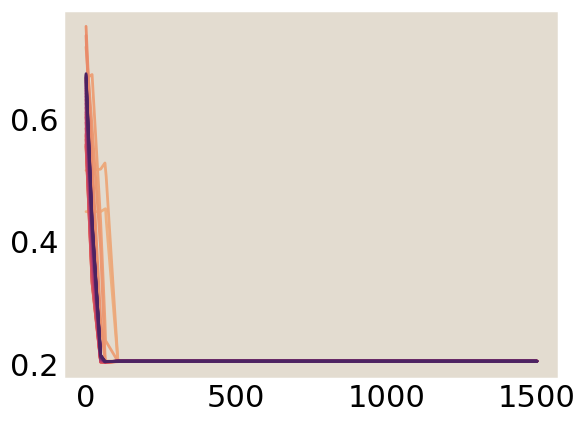

In [1127]:
for t, time in enumerate(np.unique(dftest['t'])):
    subsetdfbf = dftest[
    (dftest["t"] == time) &
    (dftest["Kd_motmt"] == combos.iloc[comboi]["Kd_motmt"]) &
    (dftest["Katp"] == combos.iloc[comboi]["Katp"]) &
    (dftest["gamma_motmax"] == combos.iloc[comboi]["gamma_motmax"]) &
    (dftest["tubbindsite"] == combos.iloc[comboi]["tubbindsite"]) &
    (dftest["D"] == combos.iloc[comboi]["D"]) &
    (dftest["feild"] == "an8(r;t)")
    ]
    subsetdfbf = subsetdfbf.sort_values(by=["X"])
    plt.plot(subsetdfbf['X']*1e6,
             subsetdfbf['feildval'], 
             alpha=1,
             lw=2,
             color=global_time(time))


# for t, time in enumerate(np.unique(tmepdf['t'])):
#     if t%1 ==0:
#         plt.scatter(tmepdf[tmepdf['t']==time]['X'],
#                    tmepdf[tmepdf['t']==time]['ATP (µM)'],
#                    color=global_time_wcomsol(time), s=2)

In [1067]:
dftest_.keys()[1]

't)/tubbindsite\n'

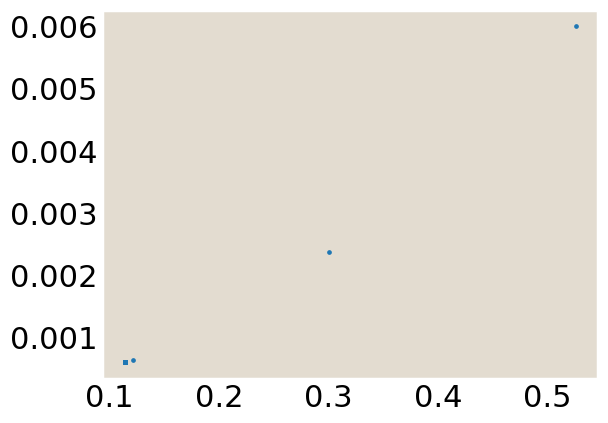

In [1069]:
plt.scatter(dftest_[' Arc length (m)          tubsig(r'], dftest_['t)/tubbindsite\n'], s=2)

In [ ]:


fig, ax = plt.subplots(1,5,figsize=(20,8), sharex=True,)

tmepdf = processDF('tubulinnotProjected.csv')
global_time_wcomsol=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([timesMT.min(), min(tmepdf['time (s)'])]), vmax=max([timesMT.max(), max(tmepdf['time (s)'])]))(time))

for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[0].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
ax[0].set_title('Tubulin', fontsize=25)
#---------------------------------------------------------------------#
tmepdf = processDF('motornotProjected.csv')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[1].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
ax[1].set_title('Total Motors', fontsize=25)
#---------------------------------------------------------------------#
tmepdf = processDF('boundmotors.csv')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[2].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
ax[2].set_title('Bound Motors', fontsize=25)
#---------------------------------------------------------------------#
tmepdf = processDF('boundfraction.csv')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[3].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)']/1000,
                   color=global_time_wcomsol(time))
ax[3].set_title('Bound Fraction', fontsize=25)
#---------------------------------------------------------------------#
tmepdf = processDF('atpProj.csv')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        ax[4].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
ax[4].set_title('ATP Projected', fontsize=25)


# ax.set_xlabel('radius (µm)', fontsize=25)
# ax.set_ylabel('(µM)', fontsize=25)
#ax.set_title('ATP Projected', fontsize=25)

ax[0].set_xlim(-5, 200)
#ax.set_ylim(25, 430)
# ax.axvline(60, c='k', lw=0.5)
# ax.axvline(100, c='k', lw=0.5)
# plt.savefig('../../analyzed_data/COMSOL/20260310-ATP_Depletion_modelADPtoo_3D_eqn-input-sigmoid_stepFtngamma/motordata.pdf', 
#             bbox_inches='tight')


######
# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # [left, bottom, width, height]

# Create the colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(tmepdf['time (s)'])/60, 
                                                                 vmax=max(tmepdf['time (s)'])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)

ax[0].set_ylabel('COMSOL')
fig.tight_layout()

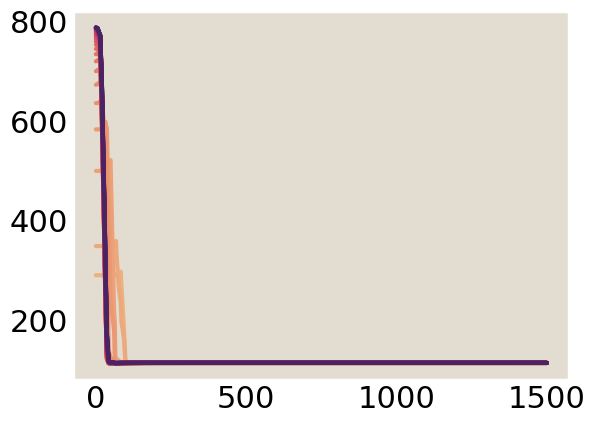

In [1130]:
tmepdf = processDF('bfplot.csv')
global_time_wcomsol=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([timesMT.min(), min(tmepdf['time (s)'])]), vmax=max([timesMT.max(), max(tmepdf['time (s)'])]))(time))

for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        plt.plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
#plt.set_title('Tubulin', fontsize=25)

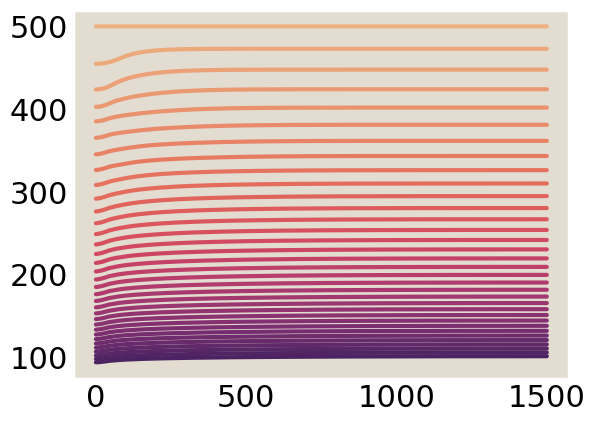

In [1148]:
tmepdf = processDF('20260414bruteforce/atp_S1_67.txt')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t%1 ==0:
        plt.plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))


In [1150]:
file_folder = '../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/'
S1df = pd.read_csv(file_folder+'S1parameters.csv')
atpfiles = glob.glob(file_folder+'*atp*.txt')

In [1198]:
S1df.head(45)

,,,,,,Table 1
sweepNumber,Kd_motmt (mol/m^3),Katp (mol/m^3),gamma_motmax (1/s),tubbindsite,D (m^2/s),NaN
1,0.03,0.0115,2,13,8E-11,NaN
2,0.03,0.0115,2,13,1.2E-10,NaN
3,0.03,0.0115,2,26,8E-11,NaN
4,0.03,0.0115,2,26,1.2E-10,NaN
5,0.03,0.0115,4,13,8E-11,NaN
6,0.03,0.0115,4,13,1.2E-10,NaN
7,0.03,0.0115,4,26,8E-11,NaN
8,0.03,0.0115,4,26,1.2E-10,NaN
9,0.03,0.023,2,13,8E-11,NaN


  0%|          | 0/72 [00:00<?, ?it/s]

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/3306984520.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


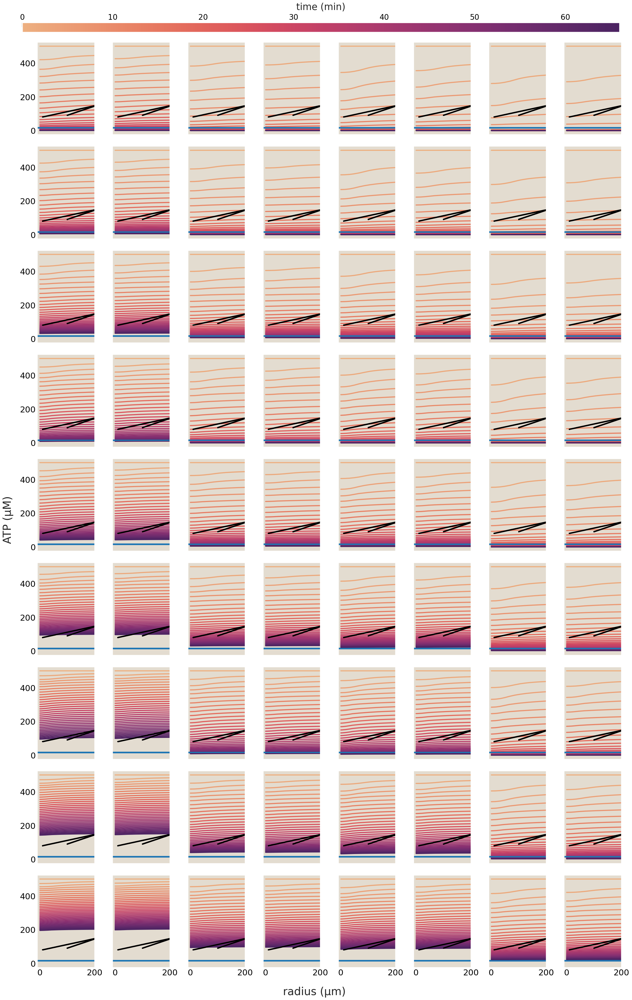

In [1269]:
global_time_wcomsol=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=0, vmax=4000)(time))

fig, ax = plt.subplots(72//8, 8, figsize=(24, 4*72//8), sharex=True, sharey=True)
for i in tqdm(range(72)):
    tmepdf = processDF('20260414bruteforce/atp_S1_'+str(i+1)+'.txt')
    for t, time in enumerate(np.unique(tmepdf['time (s)'])):
        if t%1 ==0:
            ax[int(i/8), i%8].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                       tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                       color=global_time_wcomsol(time))
            ax[int(i/8), i%8].plot([100, 210],[90, 150], color='k')
            ax[int(i/8), i%8].plot([10, 210],[80, 150], color='k')
            ax[int(i/8), i%8].axhline(15)

ax[0,0].set_xlim(-10, 200)



######
# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.01])  # [left, bottom, width, height]

# Create the colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(tmepdf['time (s)'])/60, 
                                                                 vmax=max(tmepdf['time (s)'])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)

fig.supylabel('ATP (µM)')
fig.supxlabel('radius (µm)')
fig.tight_layout()

#plt.savefig('../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/atpsweepS1.pdf', bbox_inches='tight')#, transparent=True)

In [1165]:
glob.glob('../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/*bf*.txt')

['../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/bf_S1_3.txt',
 '../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/bf_S1_27.txt',
 '../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/bf_S1_1.txt',
 '../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/bf_S1_51.txt',
 '../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/bf_S1_49.txt',
 '../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/bf_S1_25.txt']

Bound fractions:

  0%|          | 0/6 [00:00<?, ?it/s]

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/2997865140.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


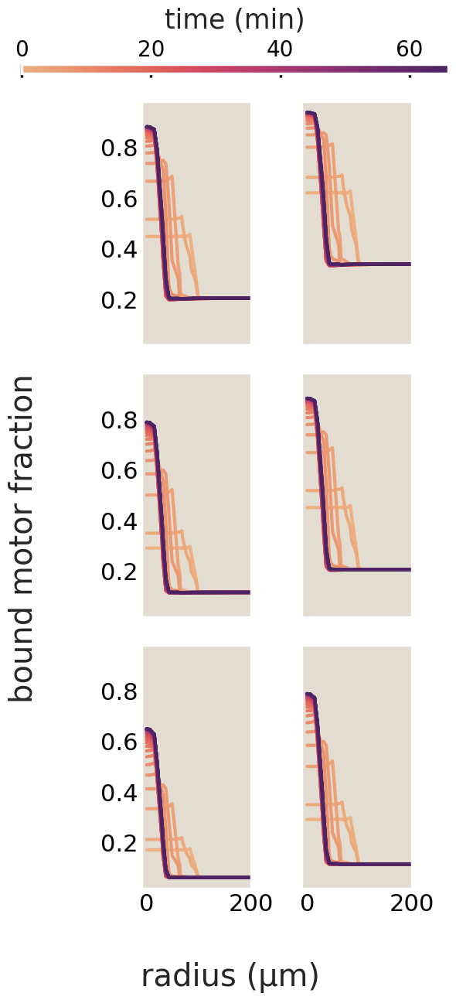

In [1170]:
global_time_wcomsol=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=0, vmax=4000)(time))

fig, ax = plt.subplots(3, 2, figsize=(6, 12), sharex=True, sharey=True)
for i, ii in enumerate(tqdm([1, 3, 25, 27, 49, 51])):
    tmepdf = processDF('20260414bruteforce/bf_S1_'+str(ii)+'.txt')
    for t, time in enumerate(np.unique(tmepdf['time (s)'])):
        if t%1 ==0:
            ax[int(i/2), i%2].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                       tmepdf[tmepdf['time (s)']==time]['ATP (µM)']/1000,
                       color=global_time_wcomsol(time))
ax[0,0].set_xlim(-10, 200)

######
# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.01])  # [left, bottom, width, height]

# Create the colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(tmepdf['time (s)'])/60, 
                                                                 vmax=max(tmepdf['time (s)'])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)

fig.supylabel('bound motor fraction')
fig.supxlabel('radius (µm)')
fig.tight_layout()

plt.savefig('../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/bfsweepS1.pdf', bbox_inches='tight')#, transparent=True)

# Compare the simulated data with the actual ATP data and look for the steepest sections and the time to deplete or finish the experiment

plot the poster child ATP data

In [1204]:
tmepdf['time (s)'].max()

np.float64(3960.0)

0.5454545454545454
0.13333333333333333
0.3333333333333333


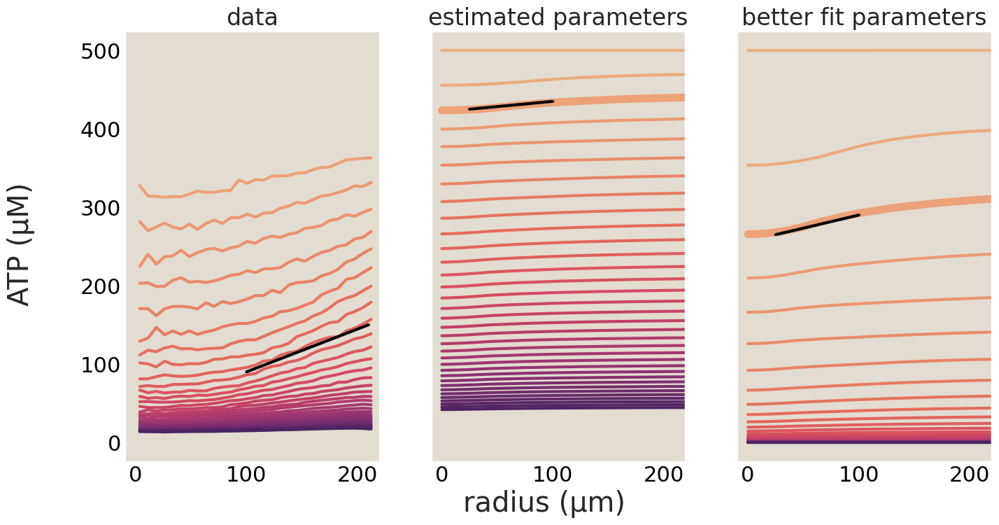

In [1255]:
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()]), vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()]))(time))

fig, ax = plt.subplots(1, 3, figsize=(16, 8), sharex=True, sharey=True)

skipnum = 6
for t, time in enumerate(h5dic_pc['timesATP'][12::skipnum]):
    if np.isin(t*skipnum+12, [62]):#[12, 62, 112, 162]):
        ax[0].plot(h5dic_pc['all_rATPbins'][t*skipnum+12]*6,
                 h5dic_pc['all_rATPavgs'][t*skipnum+12], 
                 alpha=1,
                 lw=8,
                 color=global_time(time))
    else:
        ax[0].plot(h5dic_pc['all_rATPbins'][t*skipnum+12]*6,
                 h5dic_pc['all_rATPavgs'][t*skipnum+12], 
                 alpha=1,
                 color=global_time(time))

tmepdf = processDF('20260414bruteforce/atp_S1_34.txt')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t==2:#[12, 62, 112, 162]):
        ax[1].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time),
                   lw=8)
    else:
        ax[1].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))

tmepdf = processDF('20260414bruteforce/atp_S1_39.txt')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t==2:#[12, 62, 112, 162]):
        ax[2].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time),
                   lw=8)
    else:
        ax[2].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
        
ax[0].plot([100, 210],[90, 150], color='k')
print((150-90)/(210-100))
ax[1].plot([25, 100],[425, 435], color='k')
print((435-425)/(100-25))
ax[2].plot([25, 100],[265, 290], color='k')
print((290-265)/(100-25))
#ax[0].plot([10, 210],[80, 150], color='k')
ax[1].set_xlim(-10, 220)
#ax[1].set_ylim(ax[0].get_ylim())
fig.supxlabel('radius (µm)')
fig.supylabel('ATP (µM)')
ax[0].set_title('data')
ax[1].set_title('estimated parameters')
ax[2].set_title('better fit parameters')

#plt.savefig('../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260414bruteforce/dataPlusSimBetterFit.pdf', bbox_inches='tight')#, transparent=True)

In [1259]:
len(h5dic_pc['timesATP'][12::skipnum])

32

In [1268]:
h5dic_pc['all_rATPavgs'][12::skipnum][-1]

array([14.20711403, 13.80368658, 13.73166588, 13.31454344, 13.69652911,
       13.69437196, 13.85441893, 13.93079356, 13.97074637, 14.10381221,
       14.34924124, 14.51235975, 14.67971845, 14.91199562, 15.12259932,
       15.36948765, 15.66345802, 16.04024936, 16.19120208, 16.46666147,
       16.80557679, 17.09406939, 17.35717436, 17.68751046, 17.91064495,
       18.1202824 , 18.08487274, 17.77795804, 17.06982347])

In [1238]:
np.unique(tmepdf['time (s)'])

array([   0.,  120.,  240.,  360.,  480.,  600.,  720.,  840.,  960.,
       1080., 1200., 1320., 1440., 1560., 1680., 1800., 1920., 2040.,
       2160., 2280., 2400., 2520., 2640., 2760., 2880., 3000., 3120.,
       3240., 3360., 3480., 3600., 3720., 3840., 3960.])

In [1245]:
h5dic_pc['timesATP'][12::6]

array([ 250.,  370.,  490.,  610.,  730.,  850.,  970., 1090., 1210.,
       1330., 1450., 1570., 1690., 1810., 1930., 2050., 2170., 2290.,
       2410., 2530., 2650., 2770., 2890., 3010., 3130., 3250., 3370.,
       3490., 3610., 3730., 3850., 3970.])

# S2 sweep

  0%|          | 0/27 [00:00<?, ?it/s]

/home/aduarte/am_atp/analysis/aster/ipykernel_3694390/3992356618.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


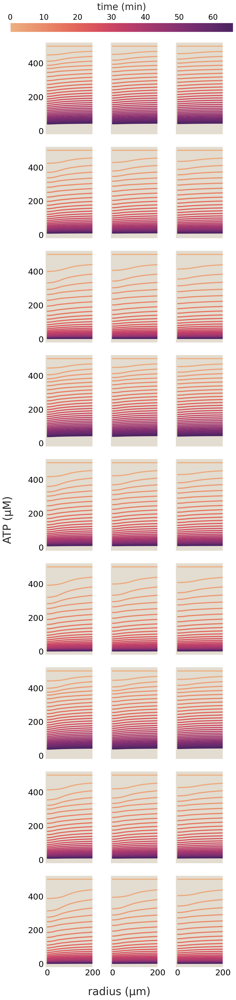

In [1339]:
global_time_wcomsol=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=0, vmax=4000)(time))

fig, ax = plt.subplots(27//3, 3, figsize=(9, 4*27//3), sharex=True, sharey=True)
for i in tqdm(range(27)):
    tmepdf = processDF('20260416_S2/atp_S2_'+str(i+1)+'.txt')
    for t, time in enumerate(np.unique(tmepdf['time (s)'])):
        if t%1 ==0:
            ax[int(i/3), i%3].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                       tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                       color=global_time_wcomsol(time))
            # ax[int(i/3), i%3].plot([100, 210],[90, 150], color='k')
            # ax[int(i/3), i%3].plot([10, 210],[80, 150], color='k')
            # ax[int(i/3), i%3].axhline(15)

ax[0,0].set_xlim(-10, 200)



######
# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.01])  # [left, bottom, width, height]

# Create the colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min(tmepdf['time (s)'])/60, 
                                                                 vmax=max(tmepdf['time (s)'])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)

fig.supylabel('ATP (µM)')
fig.supxlabel('radius (µm)')
fig.tight_layout()

plt.savefig('../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260416_S2/atpsweepS2.pdf', bbox_inches='tight')#, transparent=True)

0.5454545454545454
0.3181818181818182
0.13333333333333333
0.4666666666666667


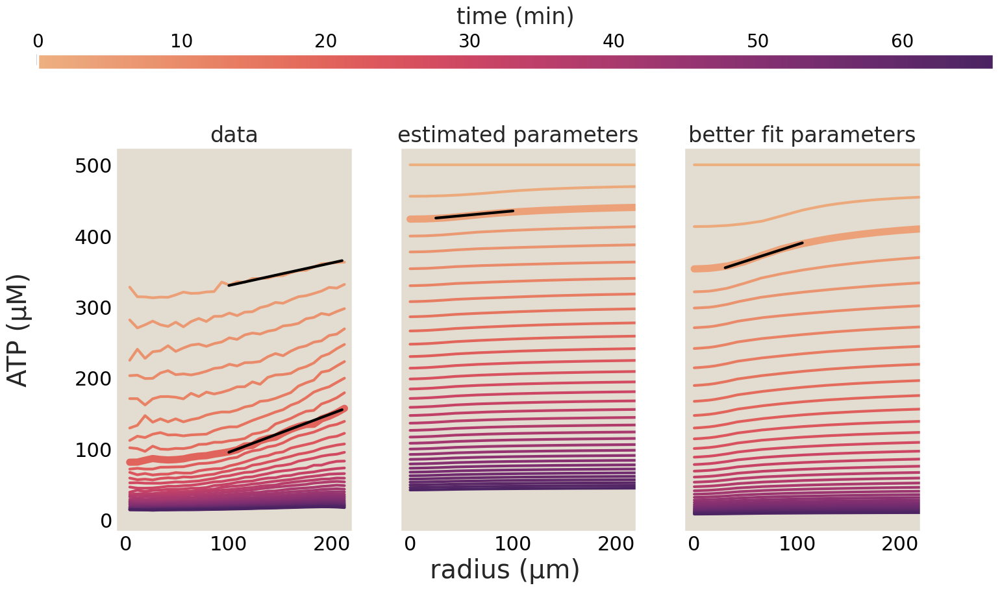

In [1346]:
global_time=lambda time:sns.color_palette("flare", as_cmap=True)(matplotlib.colors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()]), vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()]))(time))

fig, ax = plt.subplots(1, 3, figsize=(16, 8), sharex=True, sharey=True)

skipnum = 6
for t, time in enumerate(h5dic_pc['timesATP'][12::skipnum]):
    if np.isin(t*skipnum+12, [0, 60]):#[12, 62, 112, 162]):
        ax[0].plot(h5dic_pc['all_rATPbins'][t*skipnum+12]*6,
                 h5dic_pc['all_rATPavgs'][t*skipnum+12], 
                 alpha=1,
                 lw=8,
                 color=global_time(time))
    else:
        ax[0].plot(h5dic_pc['all_rATPbins'][t*skipnum+12]*6,
                 h5dic_pc['all_rATPavgs'][t*skipnum+12], 
                 alpha=1,
                 color=global_time(time))

tmepdf = processDF('20260416_S2/atp_S2_3.txt')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t==2:#[12, 62, 112, 162]):
        ax[1].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time),
                   lw=8)
    else:
        ax[1].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))

tmepdf = processDF('20260416_S2/atp_S2_22.txt')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t==2:#[12, 62, 112, 162]):
        ax[2].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time),
                   lw=8)
    else:
        ax[2].plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
        
ax[0].plot([100, 210],[95, 155], color='k')
print((155-95)/(210-100))
ax[0].plot([100, 210],[330, 365], color='k')
print((365-330)/(210-100))
ax[1].plot([25, 100],[425, 435], color='k')
print((435-425)/(100-25))
#ax[2].plot([30, 110],[315, 360], color='k')
#print((360-315)/(110-30))
ax[2].plot([30, 105],[355, 390], color='k')
print((390-355)/(105-30))
#ax[0].plot([10, 210],[80, 150], color='k')
ax[1].set_xlim(-10, 220)
#ax[1].set_ylim(ax[0].get_ylim())
fig.supxlabel('radius (µm)')
fig.supylabel('ATP (µM)')
ax[0].set_title('data')
ax[1].set_title('estimated parameters')
ax[2].set_title('better fit parameters')

######
# Adjust the top margin to make space for the colorbar
fig.subplots_adjust(top=0.85)

# Create an axis for the colorbar that spans all columns
cax = fig.add_axes([0.05, 1, 0.92, 0.03])  # [left, bottom, width, height]

# Create the colorbar
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("flare", as_cmap=True), norm=mcolors.Normalize(vmin=min([h5dic_pc['timesMot'].min(), h5dic_pc['timesATP'].min(), tmepdf['time (s)'].min()])/60, vmax=max([h5dic_pc['timesMot'].max(), h5dic_pc['timesATP'].max(), tmepdf['time (s)'].max()])/60)),
                    cax=cax, orientation='horizontal')
cbar.ax.tick_params(labelsize=20)

# Move colorbar label and ticks to the top
cbar.ax.xaxis.set_ticks_position('top')   # Move ticks to top
cbar.ax.xaxis.set_label_position('top')   # Move label to top
cbar.set_label('time (min)', fontsize=25, labelpad=10)

#plt.savefig('../../data/COMSOL/20260324-ATP_Depletion_MTandmot/trialftnTubandMot/20260416_S2/dataPlusSimBetterFit2.pdf', bbox_inches='tight')#, transparent=True)

(10.0, 20.0)

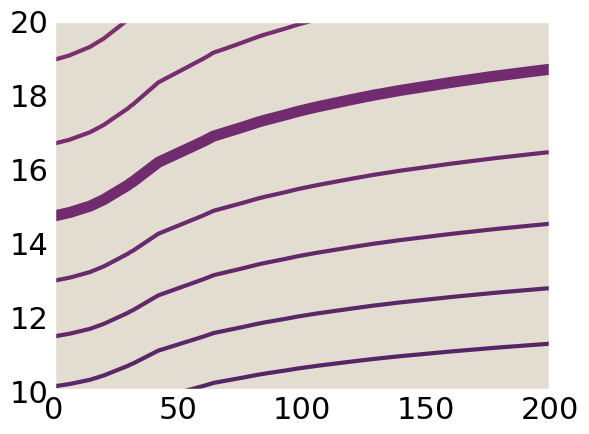

In [1331]:
tmepdf = processDF('20260416_S2/atp_S2_22.txt')
for t, time in enumerate(np.unique(tmepdf['time (s)'])):
    if t==28:#[12, 62, 112, 162]):
        plt.plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time),
                   lw=8)
    else:
        plt.plot(tmepdf[tmepdf['time (s)']==time]['position (µm)'],
                   tmepdf[tmepdf['time (s)']==time]['ATP (µM)'],
                   color=global_time_wcomsol(time))
plt.xlim(0, 200)
plt.ylim(10, 20)

In [1337]:
np.unique(tmepdf['time (s)'])[29], h5dic_pc['timesATP'][12::skipnum][8]

(np.float64(3480.0), np.float64(1210.0))

In [1291]:
h5dic_pc['timesATP'][12::skipnum]

array([ 250.,  370.,  490.,  610.,  730.,  850.,  970., 1090., 1210.,
       1330., 1450., 1570., 1690., 1810., 1930., 2050., 2170., 2290.,
       2410., 2530., 2650., 2770., 2890., 3010., 3130., 3250., 3370.,
       3490., 3610., 3730., 3850., 3970.])

In [1292]:
np.unique(tmepdf['time (s)'])

array([   0.,  120.,  240.,  360.,  480.,  600.,  720.,  840.,  960.,
       1080., 1200., 1320., 1440., 1560., 1680., 1800., 1920., 2040.,
       2160., 2280., 2400., 2520., 2640., 2760., 2880., 3000., 3120.,
       3240., 3360., 3480., 3600., 3720., 3840., 3960.])